Target -  

*   Number of citations

Input features - Keywords

*   Keywords(Index, Author)
*   Quartile
*   H-index
*   Impact Factor
*   Number of Authors
*   Abstract Title
*   Open Access





                

In [ ]:
# @title
def increase_font():
  from IPython.display import Javascript
  display(Javascript('''
  for (rule of document.styleSheets[0].cssRules){
    if (rule.selectorText=='body') {
      rule.style.fontSize = '20px'
      rule.style.color = 'darkblue'
      break
    }
  }
  '''))
increase_font()
get_ipython().events.register('pre_run_cell', increase_font)
print("Hello in ")
print("...in larger font ")

<IPython.core.display.Javascript object>

Hello in 
...in larger font 


# Imports


In [5]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import joblib
import re
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.feature_extraction.text import TfidfVectorizer

In [3]:
pip install pandas numpy matplotlib seaborn scikit-learn joblib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\mannu\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd

deepfake_rp_df = pd.read_csv(r"C:\Users\mannu\OneDrive\Desktop\minor projects\Deepfake data.csv")
deepfake_rp_df.shape
print(f"Dataset contains {deepfake_rp_df.shape[0]} rows and {deepfake_rp_df.shape[1]} columns")


Dataset contains 388 rows and 46 columns


In [11]:
pip install openpyxl

   ---------------------------------------- 0.0/250.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/250.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/250.9 kB ? eta -:--:--
   ------ -------------------------------- 41.0/250.9 kB 495.5 kB/s eta 0:00:01
   ----------------- -------------------- 112.6/250.9 kB 819.2 kB/s eta 0:00:01
   --------------------- ---------------- 143.4/250.9 kB 853.3 kB/s eta 0:00:01
   ----------------------------- -------- 194.6/250.9 kB 841.6 kB/s eta 0:00:01
   -------------------------------------  245.8/250.9 kB 888.8 kB/s eta 0:00:01
   -------------------------------------- 250.9/250.9 kB 856.5 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\mannu\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


# Section 1 Analysing data

In [8]:
# @title
deepfake_rp_df = pd.read_csv(r"C:\Users\mannu\OneDrive\Desktop\minor projects\Deepfake data.csv")
deepfake_rp_df.shape
print(f'Dataset conatains {deepfake_rp_df.shape[0]} rows and {deepfake_rp_df.shape[1]} columns')

Dataset conatains 388 rows and 46 columns


In [12]:
import pandas as pd
import re

def extract_names(author_str):
    if pd.isna(author_str):
        return []

    entries = [e.strip() for e in author_str.split(';') if e.strip()]
    names = []

    for entry in entries:
        # Remove the number part (inside parentheses)
        entry = re.sub(r"\s*\(\d+\)", "", entry).strip()

        if "," in entry:
            last, first = [part.strip() for part in entry.split(",", 1)]
            names.append(f"{first} {last}")
        else:
            names.append(entry)

    return names

# Flattened list of all names
all_names = []

# Apply the function to each row
for authors in deepfake_rp_df['Author full names']:
    all_names.extend(extract_names(authors))

# Save to Excel
output_df = pd.DataFrame(all_names, columns=["Full Name"])
output_df.to_excel("cleaned_author_names.xlsx", index=False)

print("Author names extracted and saved to 'cleaned_author_names.xlsx'")


Author names extracted and saved to 'cleaned_author_names.xlsx'


In [ ]:
pip install pandas openpyxl


<IPython.core.display.Javascript object>

In [ ]:
# @title
print(f"List of all the columns",deepfake_rp_df.columns)

<IPython.core.display.Javascript object>

List of all the columns Index(['Authors', 'Author full names', 'Author(s) ID', 'Title', 'Year',
       'Source title', 'Quartile', 'SJR', 'H-Index', 'Country', 'Volume',
       'Issue', 'Art. No.', 'Page start', 'Page end', 'Page count', 'Cited by',
       'DOI', 'Link', 'Affiliations', 'Authors with affiliations', 'Abstract',
       'Author Keywords', 'Index Keywords', 'Molecular Sequence Numbers',
       'Chemicals/CAS', 'Tradenames', 'Manufacturers', 'Funding Details',
       'Funding Texts', 'References', 'Correspondence Address', 'Editors',
       'Publisher', 'Sponsors', 'Conference name', 'Conference date',
       'Conference location', 'Conference code', 'ISSN', 'ISBN', 'CODEN',
       'PubMed ID', 'Language of Original Document',
       'Abbreviated Source Title', 'Document Type', 'Publication Stage',
       'Open Access', 'Source', 'EID'],
      dtype='object')


In [13]:
# @title
deepfake_rp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 46 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Authors                        388 non-null    object 
 1   Author full names              388 non-null    object 
 2   Author(s) ID                   388 non-null    object 
 3   Title                          388 non-null    object 
 4   Year                           388 non-null    int64  
 5   Source title                   388 non-null    object 
 6   Volume                         180 non-null    object 
 7   Issue                          83 non-null     object 
 8   Art. No.                       53 non-null     object 
 9   Page start                     235 non-null    object 
 10  Page end                       234 non-null    float64
 11  Page count                     234 non-null    float64
 12  Cited by                       388 non-null    int

In [14]:
# @title
# Check for duplicate source titles
duplicates = deepfake_rp_df[deepfake_rp_df.duplicated(subset=["Source title"], keep=False)]

# Dictionary to store mismatches
inconsistencies = {}

# Iterate over groups of duplicate source titles
for title, group in duplicates.groupby("Source title"):
    # Drop duplicate rows within the group based on the other 4 columns
    unique_rows = group.drop_duplicates(subset=["Quartile", "SJR", "H-Index", "Country"])
    # If there's more than one unique combination, there is an inconsistency
    if len(unique_rows) > 1:
        inconsistencies[title] = unique_rows

# Output the results
if inconsistencies:
    print("Inconsistent duplicate entries found:")
    for title, group in inconsistencies.items():
        print("\nSource title:", title)
        print(group)
else:
    print("All duplicate 'Source title' entries have consistent values for the other columns.")



KeyError: Index(['SJR', 'Country', 'H-Index', 'Quartile'], dtype='object')

In [ ]:
pd.options.display.max_columns = None
deepfake_rp_df.head()

<IPython.core.display.Javascript object>

,Authors,Author full names,Author(s) ID,Title,Year,Source title,Quartile,SJR,H-Index,Country,Volume,Issue,Art. No.,Page start,Page end,Page count,Cited by,DOI,Link,Affiliations,Authors with affiliations,Abstract,Author Keywords,Index Keywords,Molecular Sequence Numbers,Chemicals/CAS,Tradenames,Manufacturers,Funding Details,Funding Texts,References,Correspondence Address,Editors,Publisher,Sponsors,Conference name,Conference date,Conference location,Conference code,ISSN,ISBN,CODEN,PubMed ID,Language of Original Document,Abbreviated Source Title,Document Type,Publication Stage,Open Access,Source,EID
0,Meel P.; Raj C.; Bhawna,"Meel, Priyanka (56460308400); Raj, Chahat (572...",56460308400; 57222593125; 59564689500,A review of web infodemic analysis and detecti...,2025,International Journal of Data Science and Anal...,Q2,0.678,36,SWITZERLAND,NaN,NaN,103120,NaN,NaN,NaN,0,10.1007/s41060-025-00727-w,https://www.scopus.com/inward/record.uri?eid=2...,"Department of Information Technology, Delhi Te...","Meel P., Department of Information Technology,...",The proliferation of disinformation and misinf...,Deep Learning; Fake News Detection; Multi-moda...,Deep neural networks; Deep learning; Digital p...,NaN,NaN,NaN,NaN,NaN,NaN,"Zhang Q., Guo Z., Zhu Y., Vijayakumar P., Cast...","Bhawna; Department of Information Technology, ...",NaN,Springer Science and Business Media Deutschlan...,NaN,NaN,NaN,NaN,NaN,2364415X,NaN,NaN,NaN,English,Int. J. Data Sci. Anal.,Review,Article in press,NaN,Scopus,2-s2.0-85218264626
1,Bhat R.; Nanjundegowda R.,"Bhat, Ranjith (57693890300); Nanjundegowda, Ra...",57693890300; 56405413900,A Review on Comparative Analysis of Generative...,2025,Journal of Robotics and Control (JRC),Q2,0.435,26,INDONESIA,6,1,NaN,53,64.0,11.0,1,10.18196/jrc.v6i1.24160,https://www.scopus.com/inward/record.uri?eid=2...,"Faculty of Engineering and Technology, JAIN (D...","Bhat R., Faculty of Engineering and Technology...",Generative Adversarial Networks (GANs) are a m...,Artificial Intelligence (AI); Computer Vision ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"PirahanSiah F., Computer Vision, Deep Learning...",R. Bhat; Faculty of Engineering and Technology...,NaN,"Department of Agribusiness, Universitas Muhamm...",NaN,NaN,NaN,NaN,NaN,27155056,NaN,NaN,NaN,English,J. Robot. Control.,Article,Final,NaN,Scopus,2-s2.0-85211566508
2,Thakral K.; Agarwal H.; Narayan K.; Mittal S.;...,"Thakral, Kartik (57211539566); Agarwal, Harsh ...",57211539566; 57885819800; 57713657000; 5722114...,DeePhyNet: Toward Detecting Phylogeny in Deepf...,2025,"IEEE Transactions on Biometrics, Behavior, and...",Q1,0.969,30,US,7,1,NaN,132,145.0,13.0,0,10.1109/TBIOM.2024.3487482,https://www.scopus.com/inward/record.uri?eid=2...,"Indian Institute of Technology Jodhpur, Depart...","Thakral K., Indian Institute of Technology Jod...",Deepfakes have rapidly evolved from their ince...,deepfake detection; Deepfakes; phylogeny,Deepfake; Deepfake detection; Generation algor...,NaN,NaN,NaN,NaN,Ministry of Electronics and Information techno...,This work was supported in part by a Grant fro...,"Le T.-N., Nguyen H.H., Yamagishi J., Echizen I...",R. Singh; Indian Institute of Technology Jodhp...,NaN,Institute of Electrical and Electronics Engine...,NaN,NaN,NaN,NaN,NaN,26376407,NaN,NaN,NaN,English,IEEE Trans. Biom. Behav. Iden. Sci.,Article,Final,NaN,Scopus,2-s2.0-86000373825
3,Chauhan S.S.; Singh A.K.; Rastogi A.K.; Jain N...,"Chauhan, Surendra Singh (57258087000); Singh, ...",57258087000; 59761865900; 57331270100; 5731340...,Deepfake Detection in Picture,2025,2025 International Conference on Automation an...,NIL,NIL,NIL,NIL,NaN,NaN,NaN,359,363.0,4.0,0,10.1109/AUTOCOM64127.2025.10956280,https://www.scopus.com/inward/record.uri?eid=2...,"Srm University, Haryana, Sonipat, India; Unive...","Chauhan S.S., Srm University, Haryana, Sonipat...",With the growing prevalence of hyper-realistic...,Deep Learning; Deepfake; Face-to-Face; Image A...,Forensic engineering; Photointerpretation; Cri...,NaN,NaN,NaN,NaN,N

In [ ]:
# @title
non_null_counts = deepfake_rp_df.notnull().sum()
# non_null_counts = deepfake_rp_df.notnull()
columns_gt_600 = non_null_counts[non_null_counts > 600]

print(f'Out of the  columns only columns 26 have enough data that can be used as for our interpretation and the name of columns are \n{columns_gt_600}')

<IPython.core.display.Javascript object>

Out of the  columns only columns 26 have enough data that can be used as for our interpretation and the name of columns are 
Authors                          875
Author full names                875
Author(s) ID                     875
Title                            875
Year                             875
Source title                     875
Quartile                         875
SJR                              875
H-Index                          875
Country                          875
Cited by                         875
DOI                              844
Link                             875
Affiliations                     875
Authors with affiliations        875
Abstract                         875
Author Keywords                  782
Index Keywords                   668
References                       865
Publisher                        874
ISBN                             614
Language of Original Document    875
Abbreviated Source Title         875
Document Type           

#Section 2: Data Cleaning and Pre-processing

## Indentifying duplicate rows and removing them

In [ ]:
# @title
identifying_columns = [
    'Authors', 'Author full names', 'Author(s) ID', 'Title', 'Year',
    'Source title', 'Quartile', 'SJR', 'H-Index', 'Country', 'Volume',
    'Issue', 'Art. No.', 'Page start', 'Page end', 'Page count', 'Cited by',
    'DOI', 'Link', 'Affiliations', 'Authors with affiliations', 'Abstract',
    'Author Keywords', 'Index Keywords'
]
df_identifiers = deepfake_rp_df[identifying_columns]
duplicate_keys = ['Authors', 'Title']
print("Duplicate Rows")
duplicates = df_identifiers[df_identifiers.duplicated(subset=duplicate_keys, keep=False)]
duplicated_rows = deepfake_rp_df[deepfake_rp_df.duplicated(subset=duplicate_keys, keep=False)]
print(duplicated_rows.to_string(index=False))

<IPython.core.display.Javascript object>

Duplicate Rows
                                                                                                                                       Authors                                                                                                                                                                                                                                                                                                           Author full names                                                                                                                     Author(s) ID                                                                                                                  Title  Year             Source title Quartile   SJR H-Index Country Volume Issue Art. No. Page start  Page end  Page count  Cited by                           DOI                                                                                                                          

In [ ]:
# @title
deepfake_rp_df_deduped = deepfake_rp_df.drop_duplicates(subset=duplicate_keys, keep='first')
deepfake_rp_df_deduped.reset_index(drop=True, inplace=True)
print(f"Duplicates removed: {len(deepfake_rp_df) - len(deepfake_rp_df_deduped)}")
print(f"Remaining rows: {len(deepfake_rp_df_deduped)}")

deepfake_rp_df=deepfake_rp_df_deduped

<IPython.core.display.Javascript object>

Duplicates removed: 2
Remaining rows: 873


##Indentiying columns with all null values and dropping them

In [ ]:
# @title
dropped_columns = [col for col in deepfake_rp_df.columns if deepfake_rp_df[col].isna().all()]
deepfake_rp_df = deepfake_rp_df.dropna(axis=1, how='all')
print("Dropped columns with 0 non-null values:", dropped_columns)

<IPython.core.display.Javascript object>

Dropped columns with 0 non-null values: ['Molecular Sequence Numbers', 'Chemicals/CAS', 'Tradenames', 'Manufacturers']


In [ ]:
pd.options.display.max_columns = None
deepfake_rp_df.head(5)

<IPython.core.display.Javascript object>

,Authors,Author full names,Author(s) ID,Title,Year,Source title,Quartile,SJR,H-Index,Country,Volume,Issue,Art. No.,Page start,Page end,Page count,Cited by,DOI,Link,Affiliations,Authors with affiliations,Abstract,Author Keywords,Index Keywords,Funding Details,Funding Texts,References,Correspondence Address,Editors,Publisher,Sponsors,Conference name,Conference date,Conference location,Conference code,ISSN,ISBN,CODEN,PubMed ID,Language of Original Document,Abbreviated Source Title,Document Type,Publication Stage,Open Access,Source,EID
0,Meel P.; Raj C.; Bhawna,"Meel, Priyanka (56460308400); Raj, Chahat (572...",56460308400; 57222593125; 59564689500,A review of web infodemic analysis and detecti...,2025,International Journal of Data Science and Anal...,Q2,0.678,36,SWITZERLAND,NaN,NaN,103120,NaN,NaN,NaN,0,10.1007/s41060-025-00727-w,https://www.scopus.com/inward/record.uri?eid=2...,"Department of Information Technology, Delhi Te...","Meel P., Department of Information Technology,...",The proliferation of disinformation and misinf...,Deep Learning; Fake News Detection; Multi-moda...,Deep neural networks; Deep learning; Digital p...,NaN,NaN,"Zhang Q., Guo Z., Zhu Y., Vijayakumar P., Cast...","Bhawna; Department of Information Technology, ...",NaN,Springer Science and Business Media Deutschlan...,NaN,NaN,NaN,NaN,NaN,2364415X,NaN,NaN,NaN,English,Int. J. Data Sci. Anal.,Review,Article in press,NaN,Scopus,2-s2.0-85218264626
1,Bhat R.; Nanjundegowda R.,"Bhat, Ranjith (57693890300); Nanjundegowda, Ra...",57693890300; 56405413900,A Review on Comparative Analysis of Generative...,2025,Journal of Robotics and Control (JRC),Q2,0.435,26,INDONESIA,6,1,NaN,53,64.0,11.0,1,10.18196/jrc.v6i1.24160,https://www.scopus.com/inward/record.uri?eid=2...,"Faculty of Engineering and Technology, JAIN (D...","Bhat R., Faculty of Engineering and Technology...",Generative Adversarial Networks (GANs) are a m...,Artificial Intelligence (AI); Computer Vision ...,NaN,NaN,NaN,"PirahanSiah F., Computer Vision, Deep Learning...",R. Bhat; Faculty of Engineering and Technology...,NaN,"Department of Agribusiness, Universitas Muhamm...",NaN,NaN,NaN,NaN,NaN,27155056,NaN,NaN,NaN,English,J. Robot. Control.,Article,Final,NaN,Scopus,2-s2.0-85211566508
2,Thakral K.; Agarwal H.; Narayan K.; Mittal S.;...,"Thakral, Kartik (57211539566); Agarwal, Harsh ...",57211539566; 57885819800; 57713657000; 5722114...,DeePhyNet: Toward Detecting Phylogeny in Deepf...,2025,"IEEE Transactions on Biometrics, Behavior, and...",Q1,0.969,30,US,7,1,NaN,132,145.0,13.0,0,10.1109/TBIOM.2024.3487482,https://www.scopus.com/inward/record.uri?eid=2...,"Indian Institute of Technology Jodhpur, Depart...","Thakral K., Indian Institute of Technology Jod...",Deepfakes have rapidly evolved from their ince...,deepfake detection; Deepfakes; phylogeny,Deepfake; Deepfake detection; Generation algor...,Ministry of Electronics and Information techno...,This work was supported in part by a Grant fro...,"Le T.-N., Nguyen H.H., Yamagishi J., Echizen I...",R. Singh; Indian Institute of Technology Jodhp...,NaN,Institute of Electrical and Electronics Engine...,NaN,NaN,NaN,NaN,NaN,26376407,NaN,NaN,NaN,English,IEEE Trans. Biom. Behav. Iden. Sci.,Article,Final,NaN,Scopus,2-s2.0-86000373825
3,Chauhan S.S.; Singh A.K.; Rastogi A.K.; Jain N...,"Chauhan, Surendra Singh (57258087000); Singh, ...",57258087000; 59761865900; 57331270100; 5731340...,Deepfake Detection in Picture,2025,2025 International Conference on Automation an...,NIL,NIL,NIL,NIL,NaN,NaN,NaN,359,363.0,4.0,0,10.1109/AUTOCOM64127.2025.10956280,https://www.scopus.com/inward/record.uri?eid=2...,"Srm University, Haryana, Sonipat, India; Unive...","Chauhan S.S., Srm University, Haryana, Sonipat...",With the growing prevalence of hyper-realistic...,Deep Learning; Deepfake; Face-to-Face; Image A...,Forensic engineering; Photointerpretation; Cri...,NaN,NaN,"Balas B., Tonsager C., Face animacy is not all...",NaN,NaN,Institute of Electrical and Electronics Engine...,iNSERB,3rd IE

##Re-arranging the columns according to importance

In [ ]:
# @title
preferred_order = [
    'Title', 'Author full names', 'Year','Document Type',
    'Source title', 'Quartile', 'SJR', 'H-Index', 'Country','Affiliations',
    'Cited by','Author Keywords', 'Index Keywords', 'Open Access','Abstract', 'Funding Details', 'Publisher'
]


remaining_cols = [col for col in deepfake_rp_df.columns if col not in preferred_order]

deepfake_rp_df = deepfake_rp_df[preferred_order + remaining_cols]
deepfake_rp_df


<IPython.core.display.Javascript object>

,Title,Author full names,Year,Document Type,Source title,Quartile,SJR,H-Index,Country,Affiliations,Cited by,Author Keywords,Index Keywords,Open Access,Abstract,Funding Details,Publisher,Authors,Author(s) ID,Volume,Issue,Art. No.,Page start,Page end,Page count,DOI,Link,Authors with affiliations,Funding Texts,References,Correspondence Address,Editors,Sponsors,Conference name,Conference date,Conference location,Conference code,ISSN,ISBN,CODEN,PubMed ID,Language of Original Document,Abbreviated Source Title,Publication Stage,Source,EID
0,A review of web infodemic analysis and detecti...,"Meel, Priyanka (56460308400); Raj, Chahat (572...",2025,Review,International Journal of Data Science and Anal...,Q2,0.678,36,SWITZERLAND,"Department of Information Technology, Delhi Te...",0,Deep Learning; Fake News Detection; Multi-moda...,Deep neural networks; Deep learning; Digital p...,NaN,The proliferation of disinformation and misinf...,NaN,Springer Science and Business Media Deutschlan...,Meel P.; Raj C.; Bhawna,56460308400; 57222593125; 59564689500,NaN,NaN,103120,NaN,NaN,NaN,10.1007/s41060-025-00727-w,https://www.scopus.com/inward/record.uri?eid=2...,"Meel P., Department of Information Technology,...",NaN,"Zhang Q., Guo Z., Zhu Y., Vijayakumar P., Cast...","Bhawna; Department of Information Technology, ...",NaN,NaN,NaN,NaN,NaN,NaN,2364415X,NaN,NaN,NaN,English,Int. J. Data Sci. Anal.,Article in press,Scopus,2-s2.0-85218264626
1,A Review on Comparative Analysis of Generative...,"Bhat, Ranjith (57693890300); Nanjundegowda, Ra...",2025,Article,Journal of Robotics and Control (JRC),Q2,0.435,26,INDONESIA,"Faculty of Engineering and Technology, JAIN (D...",1,Artificial Intelligence (AI); Computer Vision ...,NaN,NaN,Generative Adversarial Networks (GANs) are a m...,NaN,"Department of Agribusiness, Universitas Muhamm...",Bhat R.; Nanjundegowda R.,57693890300; 56405413900,6,1,NaN,53,64.0,11.0,10.18196/jrc.v6i1.24160,https://www.scopus.com/inward/record.uri?eid=2...,"Bhat R., Faculty of Engineering and Technology...",NaN,"PirahanSiah F., Computer Vision, Deep Learning...",R. Bhat; Faculty of Engineering and Technology...,NaN,NaN,NaN,NaN,NaN,NaN,27155056,NaN,NaN,NaN,English,J. Robot. Control.,Final,Scopus,2-s2.0-85211566508
2,DeePhyNet: Toward Detecting Phylogeny in Deepf...,"Thakral, Kartik (57211539566); Agarwal, Harsh ...",2025,Article,"IEEE Transactions on Biometrics, Behavior, and...",Q1,0.969,30,US,"Indian Institute of Technology Jodhpur, Depart...",0,deepfake detection; Deepfakes; phylogeny,Deepfake; Deepfake detection; Generation algor...,NaN,Deepfakes have rapidly evolved from their ince...,Ministry of Electronics and Information techno...,Institute of Electrical and Electronics Engine...,Thakral K.; Agarwal H.; Narayan K.; Mittal S.;...,57211539566; 57885819800; 57713657000; 5722114...,7,1,NaN,132,145.0,13.0,10.1109/TBIOM.2024.3487482,https://www.scopus.com/inward/record.uri?eid=2...,"Thakral K., Indian Institute of Technology Jod...",This work was supported in part by a Grant fro...,"Le T.-N., Nguyen H.H., Yamagishi J., Echizen I...",R. Singh; Indian Institute of Technology Jodhp...,NaN,NaN,NaN,NaN,NaN,NaN,26376407,NaN,NaN,NaN,English,IEEE Trans. Biom. Behav. Iden. Sci.,Final,Scopus,2-s2.0-86000373825
3,Deepfake Detection in Picture,"Chauhan, Surendra Singh (57258087000); Singh, ...",2025,Conference paper,2025 International Conference on Automation an...,NIL,NIL,NIL,NIL,"Srm University, Haryana, Sonipat, India; Unive...",0,Deep Learning; Deepfake; Face-to-Face; Image A...,Forensic engineering; Photointerpretation; Cri...,NaN,With the growing prevalence of hyper-realistic...,NaN,Institute of Electrical and Electronics Engine...,Chauhan S.S.; Singh A.K.; Rastogi A.K.; Jain N...,57258087000; 59761865900; 57331270100; 5731340...,NaN,NaN,NaN,359,363.0,4.0,10.1109/AUTOCOM64127.2025.10956280,https://www.scopus.com/inward/record.uri?eid=2...,"Chauhan S.S., Srm University, Haryana, Sonipat...",NaN,"Balas B., Tonsager C., Face animacy is not all...",

## Conclusion of section 2

In [ ]:
# @title
deepfake_rp_df.shape
print(f'Dataset after cleaning conatains {deepfake_rp_df.shape[0]} rows and {deepfake_rp_df.shape[1]} columns')

<IPython.core.display.Javascript object>

Dataset after cleaning conatains 873 rows and 46 columns


# Section 3: Exploratory data analysis (EDA)

<IPython.core.display.Javascript object>

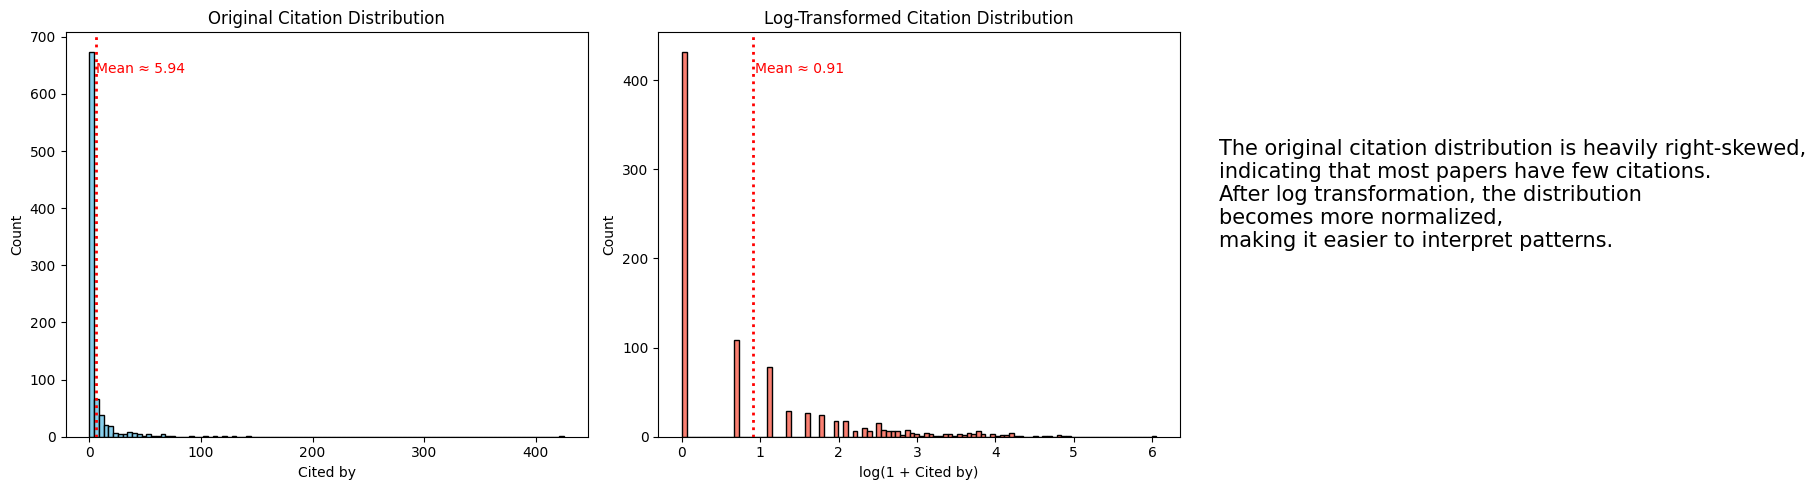

In [ ]:
# @title
deepfake_rp_df['Cited_by_log'] = np.log1p(deepfake_rp_df['Cited by'])

mean_original = deepfake_rp_df['Cited by'].mean()
mean_log = deepfake_rp_df['Cited_by_log'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(deepfake_rp_df['Cited by'], bins=100, color='skyblue', edgecolor='black')
axes[0].axvline(mean_original, color='red', linestyle='dotted', linewidth=2)
axes[0].text(mean_original + mean_original * 0.02, axes[0].get_ylim()[1]*0.9,
             f"Mean ≈ {mean_original:.2f}", color='red')
axes[0].set_title("Original Citation Distribution")
axes[0].set_xlabel("Cited by")
axes[0].set_ylabel("Count")

axes[1].hist(deepfake_rp_df['Cited_by_log'], bins=100, color='salmon', edgecolor='black')
axes[1].axvline(mean_log, color='red', linestyle='dotted', linewidth=2)
axes[1].text(mean_log + mean_log * 0.02, axes[1].get_ylim()[1]*0.9,
             f"Mean ≈ {mean_log:.2f}", color='red')
axes[1].set_title("Log-Transformed Citation Distribution")
axes[1].set_xlabel("log(1 + Cited by)")
axes[1].set_ylabel("Count")

plt.tight_layout()
fig.text(
    1.02, 0.6,
    "The original citation distribution is heavily right-skewed,\n"
    "indicating that most papers have few citations.\n"
    "After log transformation, the distribution \n"
    "becomes more normalized,\n"
    "making it easier to interpret patterns.",
    ha='left', va='center', fontsize=15
)
plt.show()

In [ ]:
deepfake_rp_df.set_index('Country', inplace=True)

countries = deepfake_rp_df.index.tolist()
quartiles = ['Q1', 'Q2', 'Q3', 'Q4']
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, country in enumerate(countries):
    axes[i].bar(quartiles, df.loc[country], color=colors)
    axes[i].set_title(f"{country}")
    axes[i].set_ylabel("Number of Journals")
    axes[i].set_ylim(0, max(deepfake_rp_df.max()) + 50)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle("Quartile Distribution of Journals by Country", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

<IPython.core.display.Javascript object>

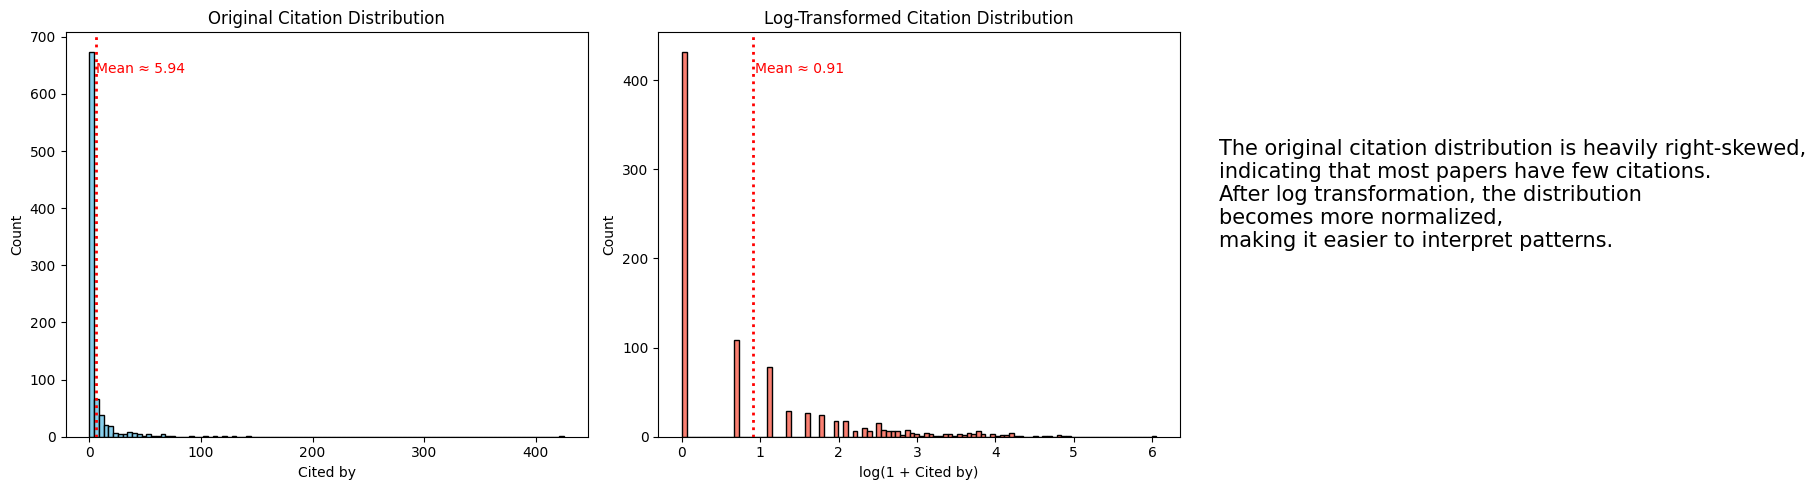

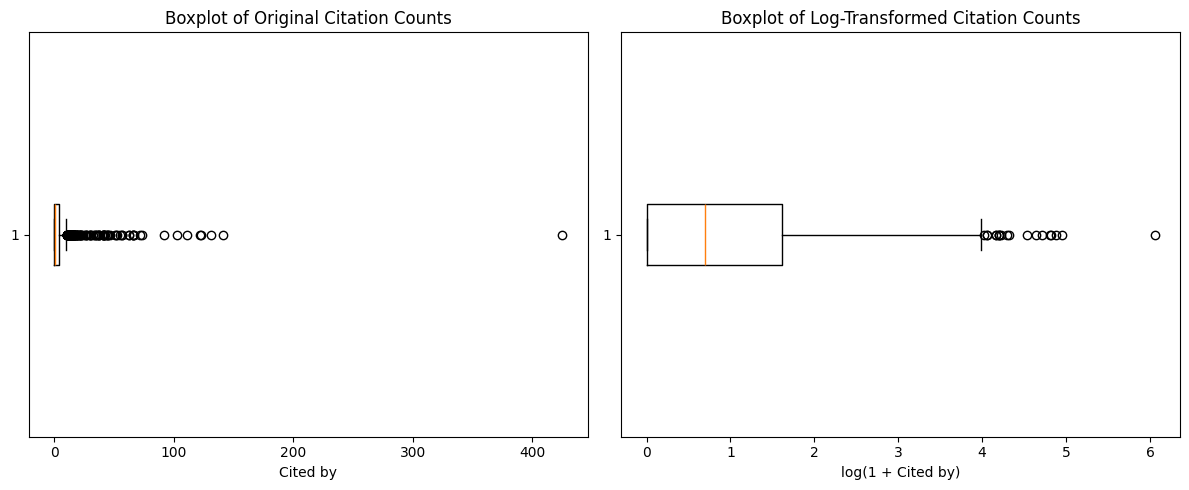

Number of outliers: 75


In [ ]:
# @title
deepfake_rp_df['Cited_by_log'] = np.log1p(deepfake_rp_df['Cited by'])

mean_original = deepfake_rp_df['Cited by'].mean()
mean_log = deepfake_rp_df['Cited_by_log'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(deepfake_rp_df['Cited by'], bins=100, color='skyblue', edgecolor='black')
axes[0].axvline(mean_original, color='red', linestyle='dotted', linewidth=2)
axes[0].text(mean_original + mean_original * 0.02, axes[0].get_ylim()[1]*0.9,
             f"Mean ≈ {mean_original:.2f}", color='red')
axes[0].set_title("Original Citation Distribution")
axes[0].set_xlabel("Cited by")
axes[0].set_ylabel("Count")

axes[1].hist(deepfake_rp_df['Cited_by_log'], bins=100, color='salmon', edgecolor='black')
axes[1].axvline(mean_log, color='red', linestyle='dotted', linewidth=2)
axes[1].text(mean_log + mean_log * 0.02, axes[1].get_ylim()[1]*0.9,
             f"Mean ≈ {mean_log:.2f}", color='red')
axes[1].set_title("Log-Transformed Citation Distribution")
axes[1].set_xlabel("log(1 + Cited by)")
axes[1].set_ylabel("Count")

plt.tight_layout()
fig.text(
    1.02, 0.6,
    "The original citation distribution is heavily right-skewed,\n"
    "indicating that most papers have few citations.\n"
    "After log transformation, the distribution \n"
    "becomes more normalized,\n"
    "making it easier to interpret patterns.",
    ha='left', va='center', fontsize=15
)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(deepfake_rp_df['Cited by'], vert=False)
axes[0].set_title("Boxplot of Original Citation Counts")
axes[0].set_xlabel("Cited by")

axes[1].boxplot(deepfake_rp_df['Cited_by_log'], vert=False)
axes[1].set_title("Boxplot of Log-Transformed Citation Counts")
axes[1].set_xlabel("log(1 + Cited by)")

plt.tight_layout()
plt.show()

Q1 = deepfake_rp_df['Cited by'].quantile(0.25)
Q3 = deepfake_rp_df['Cited by'].quantile(0.75)
IQR = Q3 - Q1

outliers = deepfake_rp_df[
    (deepfake_rp_df['Cited by'] < Q1 - 3 * IQR) |
    (deepfake_rp_df['Cited by'] > Q3 + 3 * IQR)
]

print(f"Number of outliers: {len(outliers)}")

<IPython.core.display.Javascript object>

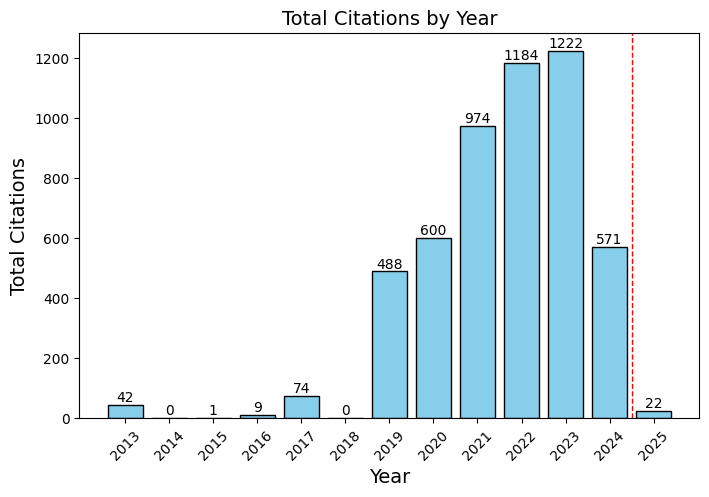

In [ ]:
# @title
all_years = np.arange(deepfake_rp_df['Year'].min(), deepfake_rp_df['Year'].max() + 1)

yearly_citations = deepfake_rp_df.groupby('Year')['Cited by'].sum().reindex(all_years, fill_value=0).reset_index()
yearly_citations.columns = ['Year', 'Cited by']

plt.figure(figsize=(8, 5))
bars = plt.bar(yearly_citations['Year'], yearly_citations['Cited by'], color='skyblue', edgecolor='black')
plt.title("Total Citations by Year", fontsize =14)
plt.xlabel("Year", fontsize = 14)
plt.ylabel("Total Citations", fontsize =14)
plt.xticks(yearly_citations['Year'], rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{int(height)}', ha='center', va='bottom', fontsize=10)

years = yearly_citations['Year'].tolist()
if 2024 in years and 2025 in years:
    idx_2024 = years.index(2024)
    idx_2025 = years.index(2025)
    x_pos = (bars[idx_2024].get_x() + bars[idx_2024].get_width() + bars[idx_2025].get_x()) / 2
    plt.axvline(x=x_pos, color='red', linestyle='--', linewidth=1)

# plt.text(0.02,0.02, '-- shows that the data is completed till \n 2024 and the data of 2025 is partial ', color = 'red')


# plt.tight_layout()

plt.show()


<IPython.core.display.Javascript object>

Total Unique Source Titles: 492 




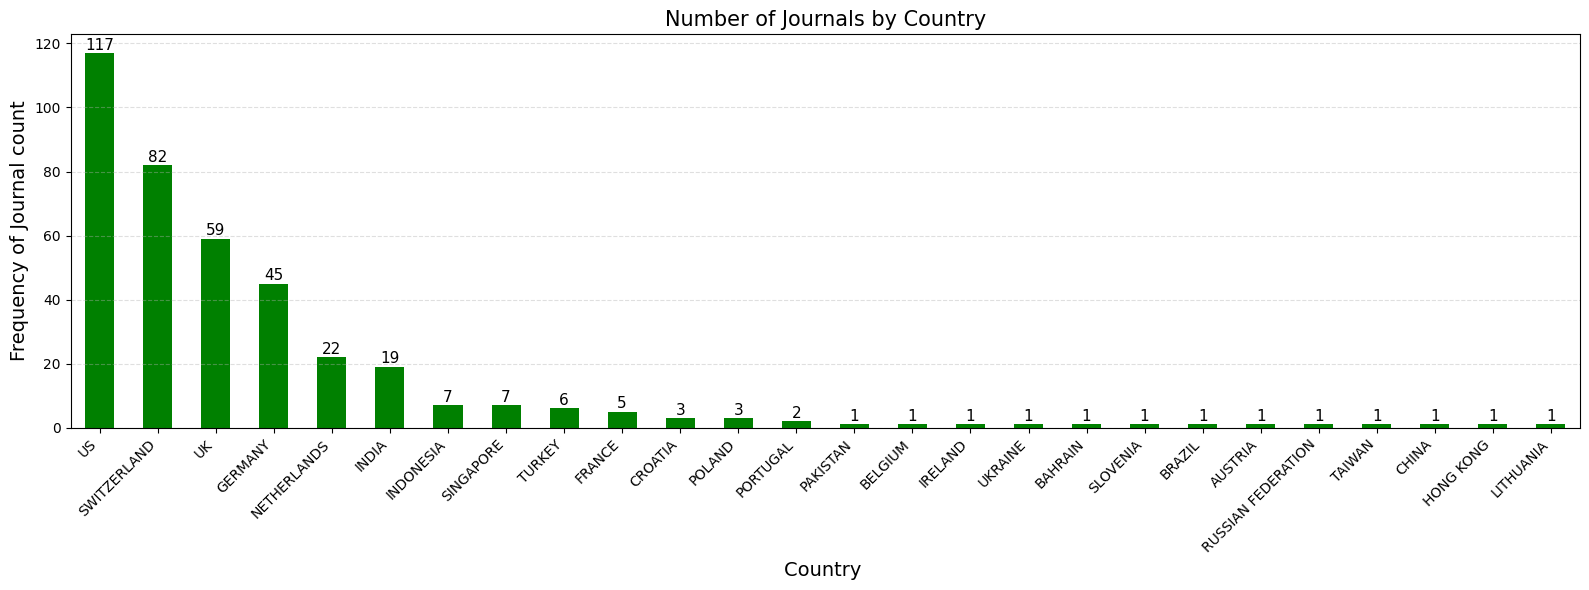

In [ ]:
# @title

filtered_df = deepfake_rp_df[deepfake_rp_df['Country'].notna() & (deepfake_rp_df['Country'] != 'NIL')]
unique_title = deepfake_rp_df['Source title'].nunique()
print("Total Unique Source Titles:", unique_title, "\n\n")

country_counts = filtered_df['Country'].value_counts()

fig, ax = plt.subplots(figsize=(16, 6))

country_counts.plot(kind='bar', color='green', ax=ax)

for i, value in enumerate(country_counts):
    ax.text(i, value + 0.1, str(value), ha='center', va='bottom', fontsize=11)

ax.set_title('Number of Journals by Country', fontsize =15)
ax.set_xlabel('Country ', fontsize =14 )
ax.set_ylabel('Frequency of Journal count', fontsize =14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.4)


plt.tight_layout()
plt.show()


<IPython.core.display.Javascript object>

<ipython-input-22-5880f31f21de>:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Year"] = df["Year"].astype(int)


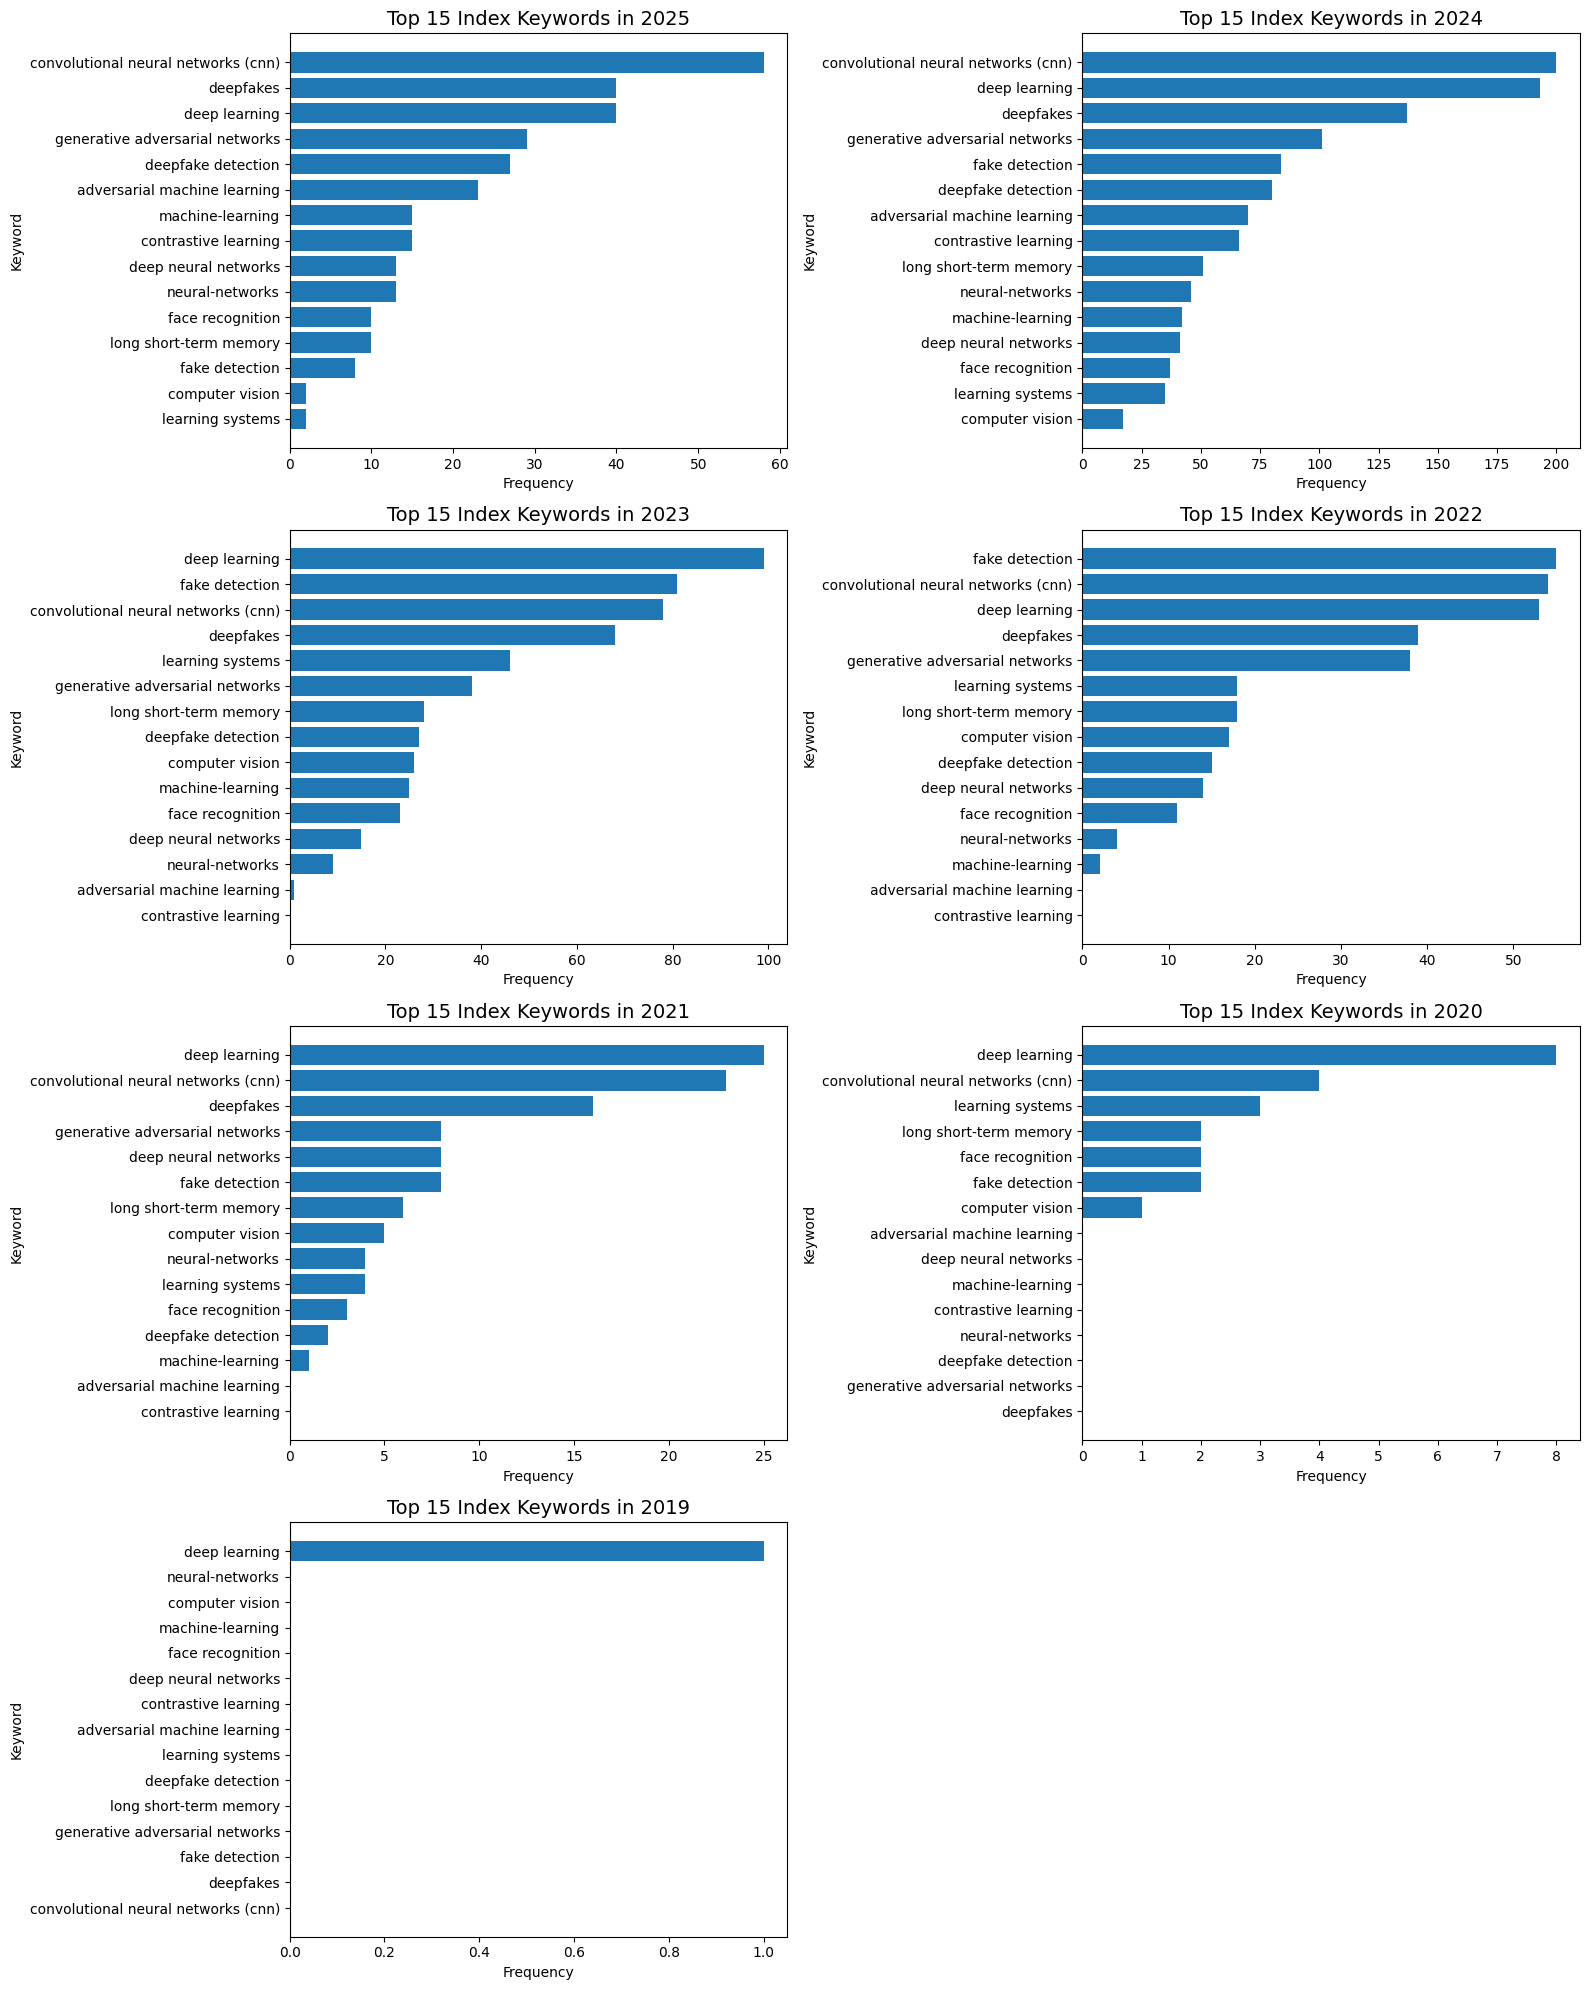

In [ ]:
# @title
singular_plural_map = {
    'deepfake': 'deepfakes',
    'gan': 'generative adversarial networks',
    'gans': 'generative adversarial networks',
    'generative adversarial network': 'generative adversarial networks',
    'generative ai': 'generative adversarial networks',
    'generative adversarial networks (gan)': 'generative adversarial networks',
    'generative adversarial network (gan)': 'generative adversarial networks',
    'generative adversarial networks (gans)': 'generative adversarial networks',
    'deep fake': 'deepfakes',
    'deep-fake': 'deepfakes',
    'deep fakes': 'deepfakes',
    'cnn': 'convolutional neural networks (cnn)',
    'convolutional neural network (cnn)': 'convolutional neural networks (cnn)',
    'convolutional neural networks (cnns)': 'convolutional neural networks (cnn)',
    'convolutional neural networks': 'convolutional neural networks (cnn)',
    'convolutional neural network': 'convolutional neural networks (cnn)',
    'convolution neural networks': 'convolutional neural networks (cnn)',
    'convolution neural network': 'convolutional neural networks (cnn)',
    'deep fake detection': 'deepfake detection',
    'face swapping': 'face swap',
    'faceswap': 'face swap',
    'lstm': 'long short-term memory',
    'long short-term memory (lstm)': 'long short-term memory',
    'long-short term memory (lstm)': 'long short-term memory',
    'recurrent neural network': 'recurrent neural network (rnn)',
    'rnn': 'recurrent neural network (rnn)',
    'ai': 'artificial intelligence (ai)',
    'artificial intelligence ': 'artificial intelligence (ai)',
    'artificial intelligence': 'artificial intelligence (ai)',
    'fake news': 'fake news detection',
    'audio deepfake': 'audio deepfake detection'
}
def normalize_keyword(kw):
    return singular_plural_map.get(kw.strip().lower(), kw.strip().lower())

def extract_keywords(keyword_string):
    raw_keywords = str(keyword_string).split(';')
    return [normalize_keyword(k) for k in raw_keywords if k.strip()]

df = deepfake_rp_df.dropna(subset=["Year", "Index Keywords"])
df["Year"] = df["Year"].astype(int)
df = df[df["Year"] >= 2019]
df["Normalized_Keywords"] = df["Index Keywords"].apply(extract_keywords)

keyword_counts_by_year = {}
for _, row in df.iterrows():
    year = row["Year"]
    keywords = row["Normalized_Keywords"]
    if year not in keyword_counts_by_year:
        keyword_counts_by_year[year] = Counter()
    keyword_counts_by_year[year].update(keywords)


all_keywords = set(k for c in keyword_counts_by_year.values() for k in c)
data = []
for year in sorted(keyword_counts_by_year.keys()):
    row = {"Year": year}
    for kw in all_keywords:
        row[kw] = keyword_counts_by_year[year][kw]
    data.append(row)

keyword_df = pd.DataFrame(data).fillna(0).set_index("Year")

top_n = 15
top_keywords = keyword_df.sum().sort_values(ascending=False).head(top_n).index
filtered_df = keyword_df[top_keywords]


years = sorted(filtered_df.index, reverse=True)
n_years = len(years)
ncols = 2
nrows = (n_years + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 5 * nrows))
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]
    year_data = filtered_df.loc[year].sort_values(ascending=True)

    ax.barh(year_data.index, year_data.values)  # <-- default color
    ax.set_title(f"Top {top_n} Index Keywords in {year}", fontsize=14)
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Keyword")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Country wise distribution in research paper??

<IPython.core.display.Javascript object>

<ipython-input-23-3bfdef776c28>:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Year"] = df["Year"].astype(int)


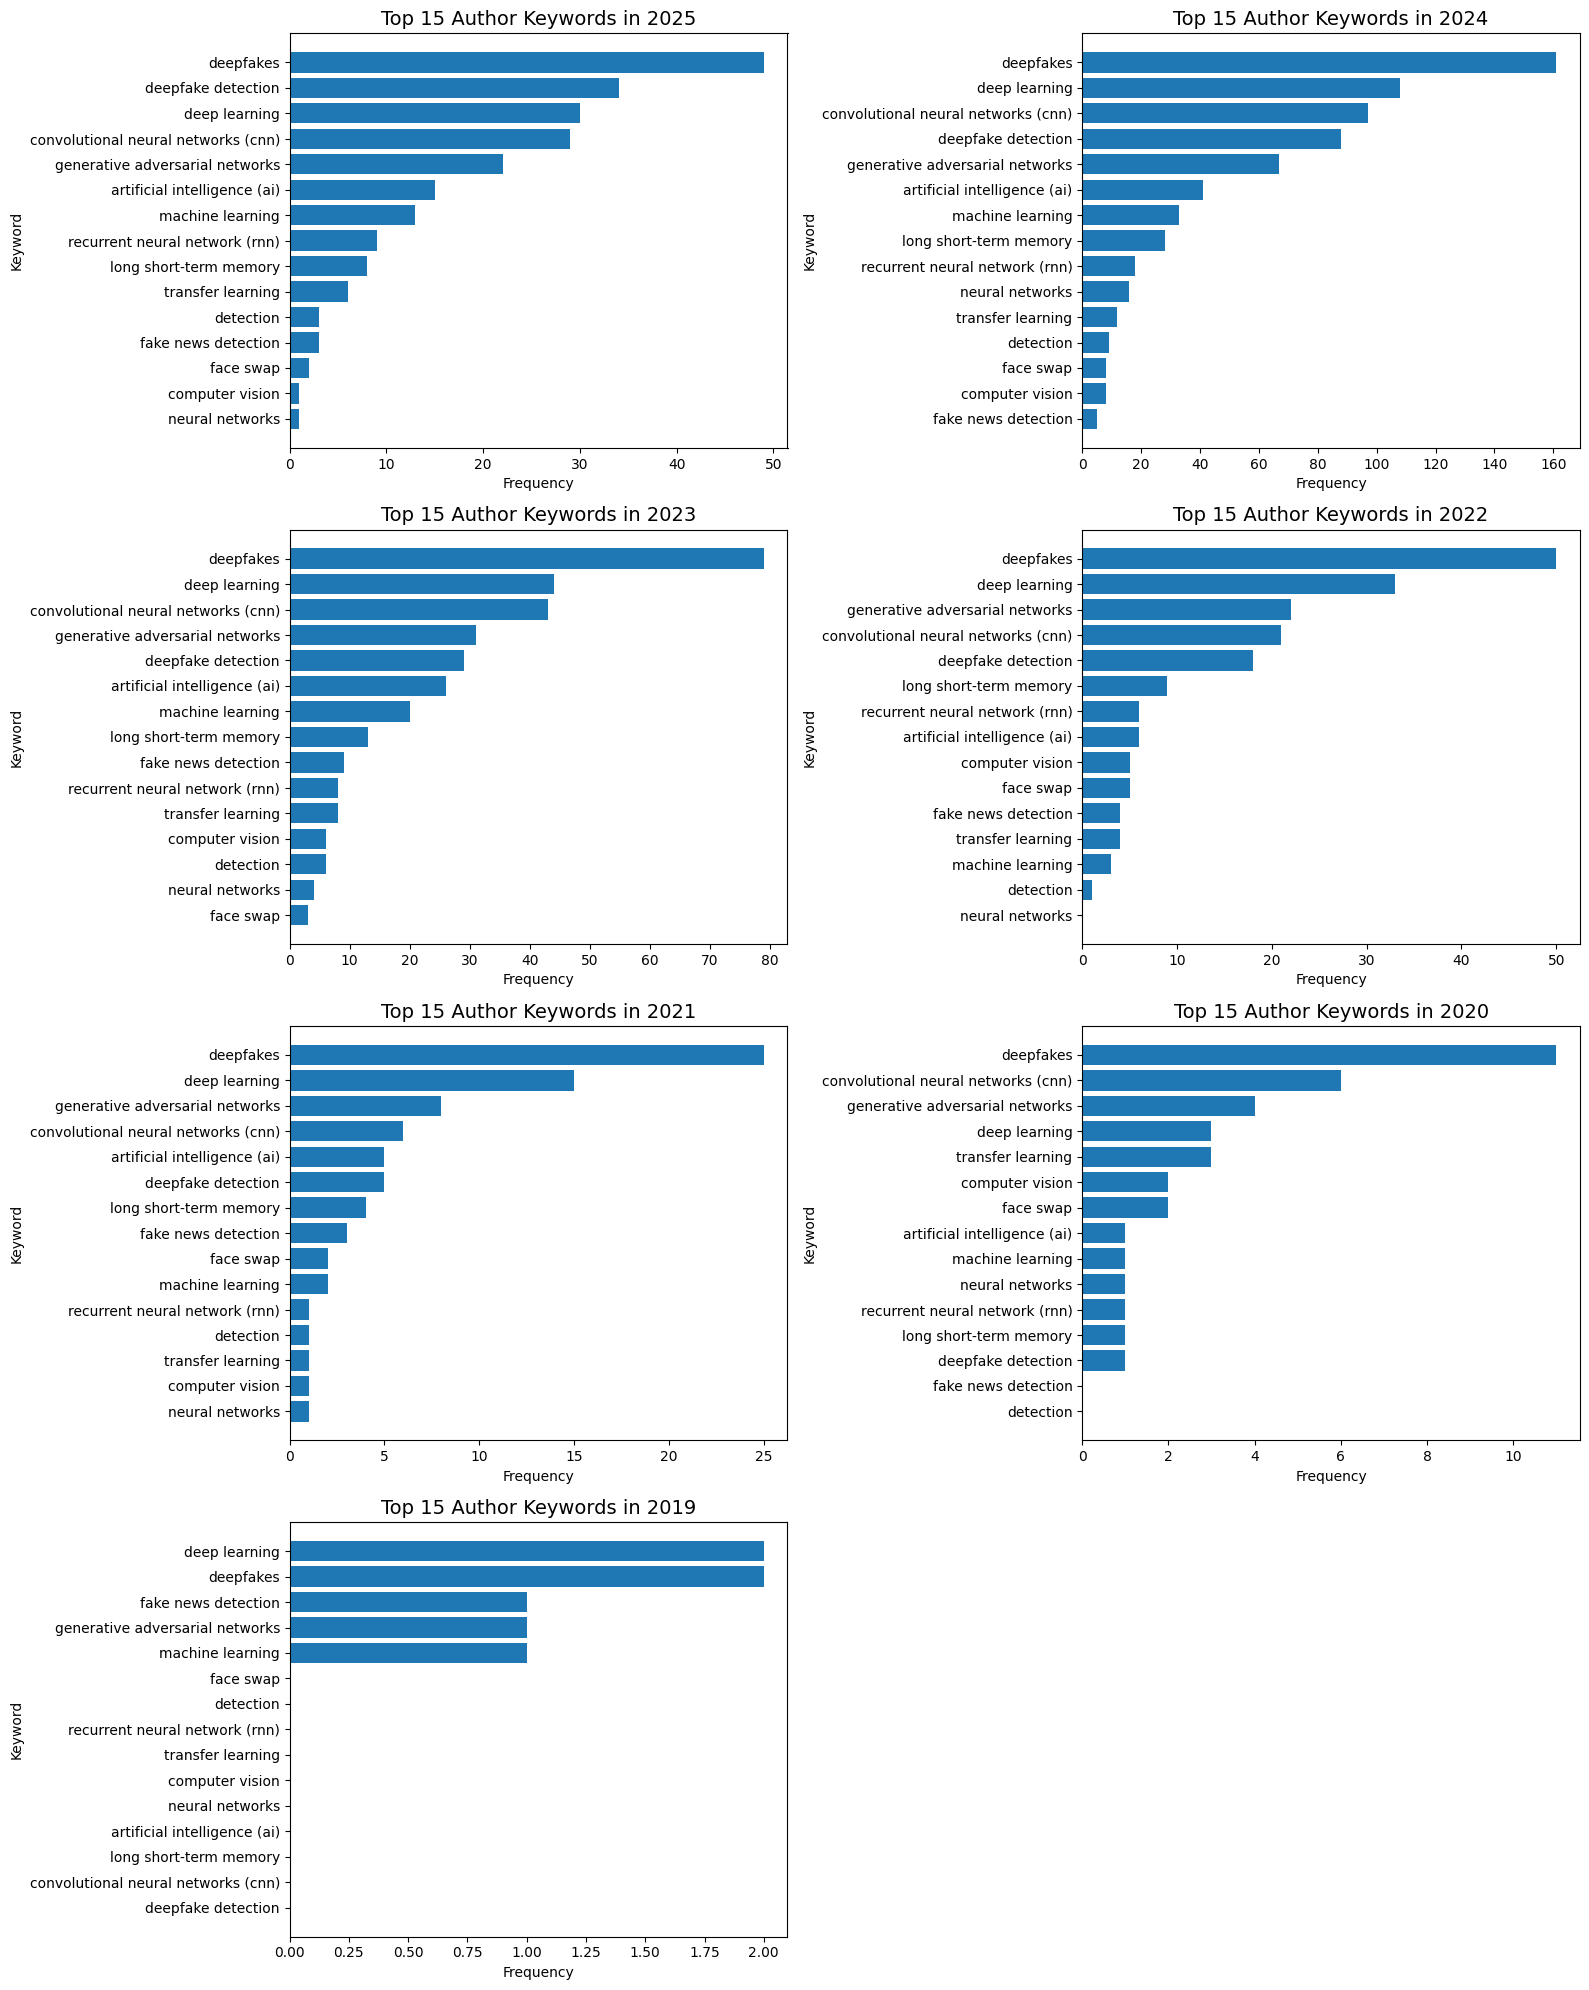

In [ ]:
# @title
singular_plural_map = {
    'deepfake': 'deepfakes',
    'gan': 'generative adversarial networks',
    'gans': 'generative adversarial networks',
    'generative adversarial network': 'generative adversarial networks',
    'generative ai': 'generative adversarial networks',
    'generative adversarial networks (gan)': 'generative adversarial networks',
    'generative adversarial network (gan)': 'generative adversarial networks',
    'generative adversarial networks (gans)': 'generative adversarial networks',
    'deep fake': 'deepfakes',
    'deep-fake': 'deepfakes',
    'deep fakes': 'deepfakes',
    'cnn': 'convolutional neural networks (cnn)',
    'convolutional neural network (cnn)': 'convolutional neural networks (cnn)',
    'convolutional neural networks (cnns)': 'convolutional neural networks (cnn)',
    'convolutional neural networks': 'convolutional neural networks (cnn)',
    'convolutional neural network': 'convolutional neural networks (cnn)',
    'convolution neural networks': 'convolutional neural networks (cnn)',
    'convolution neural network': 'convolutional neural networks (cnn)',
    'deep fake detection': 'deepfake detection',
    'face swapping': 'face swap',
    'faceswap': 'face swap',
    'lstm': 'long short-term memory',
    'long short-term memory (lstm)': 'long short-term memory',
    'long-short term memory (lstm)': 'long short-term memory',
    'recurrent neural network': 'recurrent neural network (rnn)',
    'rnn': 'recurrent neural network (rnn)',
    'ai': 'artificial intelligence (ai)',
    'artificial intelligence ': 'artificial intelligence (ai)',
    'artificial intelligence': 'artificial intelligence (ai)',
    'fake news': 'fake news detection',
    'audio deepfake': 'audio deepfake detection'
}

def normalize_keyword(kw):
    kw = kw.strip().lower()
    return singular_plural_map.get(kw, kw)

def extract_keywords(keyword_string):
    raw_keywords = str(keyword_string).split(';')
    return [normalize_keyword(k) for k in raw_keywords if k.strip()]

df = deepfake_rp_df.dropna(subset=["Year", "Author Keywords"])
df["Year"] = df["Year"].astype(int)
df = df[df["Year"] >= 2019]
df["Normalized_Keywords"] = df["Author Keywords"].apply(extract_keywords)

keyword_counts_by_year = {}
for _, row in df.iterrows():
    year = row["Year"]
    keywords = row["Normalized_Keywords"]
    if year not in keyword_counts_by_year:
        keyword_counts_by_year[year] = Counter()
    keyword_counts_by_year[year].update(keywords)

all_keywords = set(k for year_data in keyword_counts_by_year.values() for k in year_data)
data = []
for year in sorted(keyword_counts_by_year.keys()):
    row = {"Year": year}
    for kw in all_keywords:
        row[kw] = keyword_counts_by_year[year][kw]
    data.append(row)

keyword_df = pd.DataFrame(data).fillna(0).set_index("Year")

top_n = 15
top_keywords = keyword_df.sum().sort_values(ascending=False).head(top_n).index
filtered_df = keyword_df[top_keywords]

years = sorted(filtered_df.index, reverse=True)
n_years = len(years)
ncols = 2
nrows = (n_years + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 5 * nrows))
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]
    year_data = filtered_df.loc[year].sort_values(ascending=True)

    ax.barh(year_data.index, year_data.values)  # Use default color cycle
    ax.set_title(f"Top {top_n} Author Keywords in {year}", fontsize=14)
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Keyword")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


The above graph shows the top 15 keywords that have been used and how their use have been changing over time, it can be noted that in 2024 almost all words showed inclied

<IPython.core.display.Javascript object>

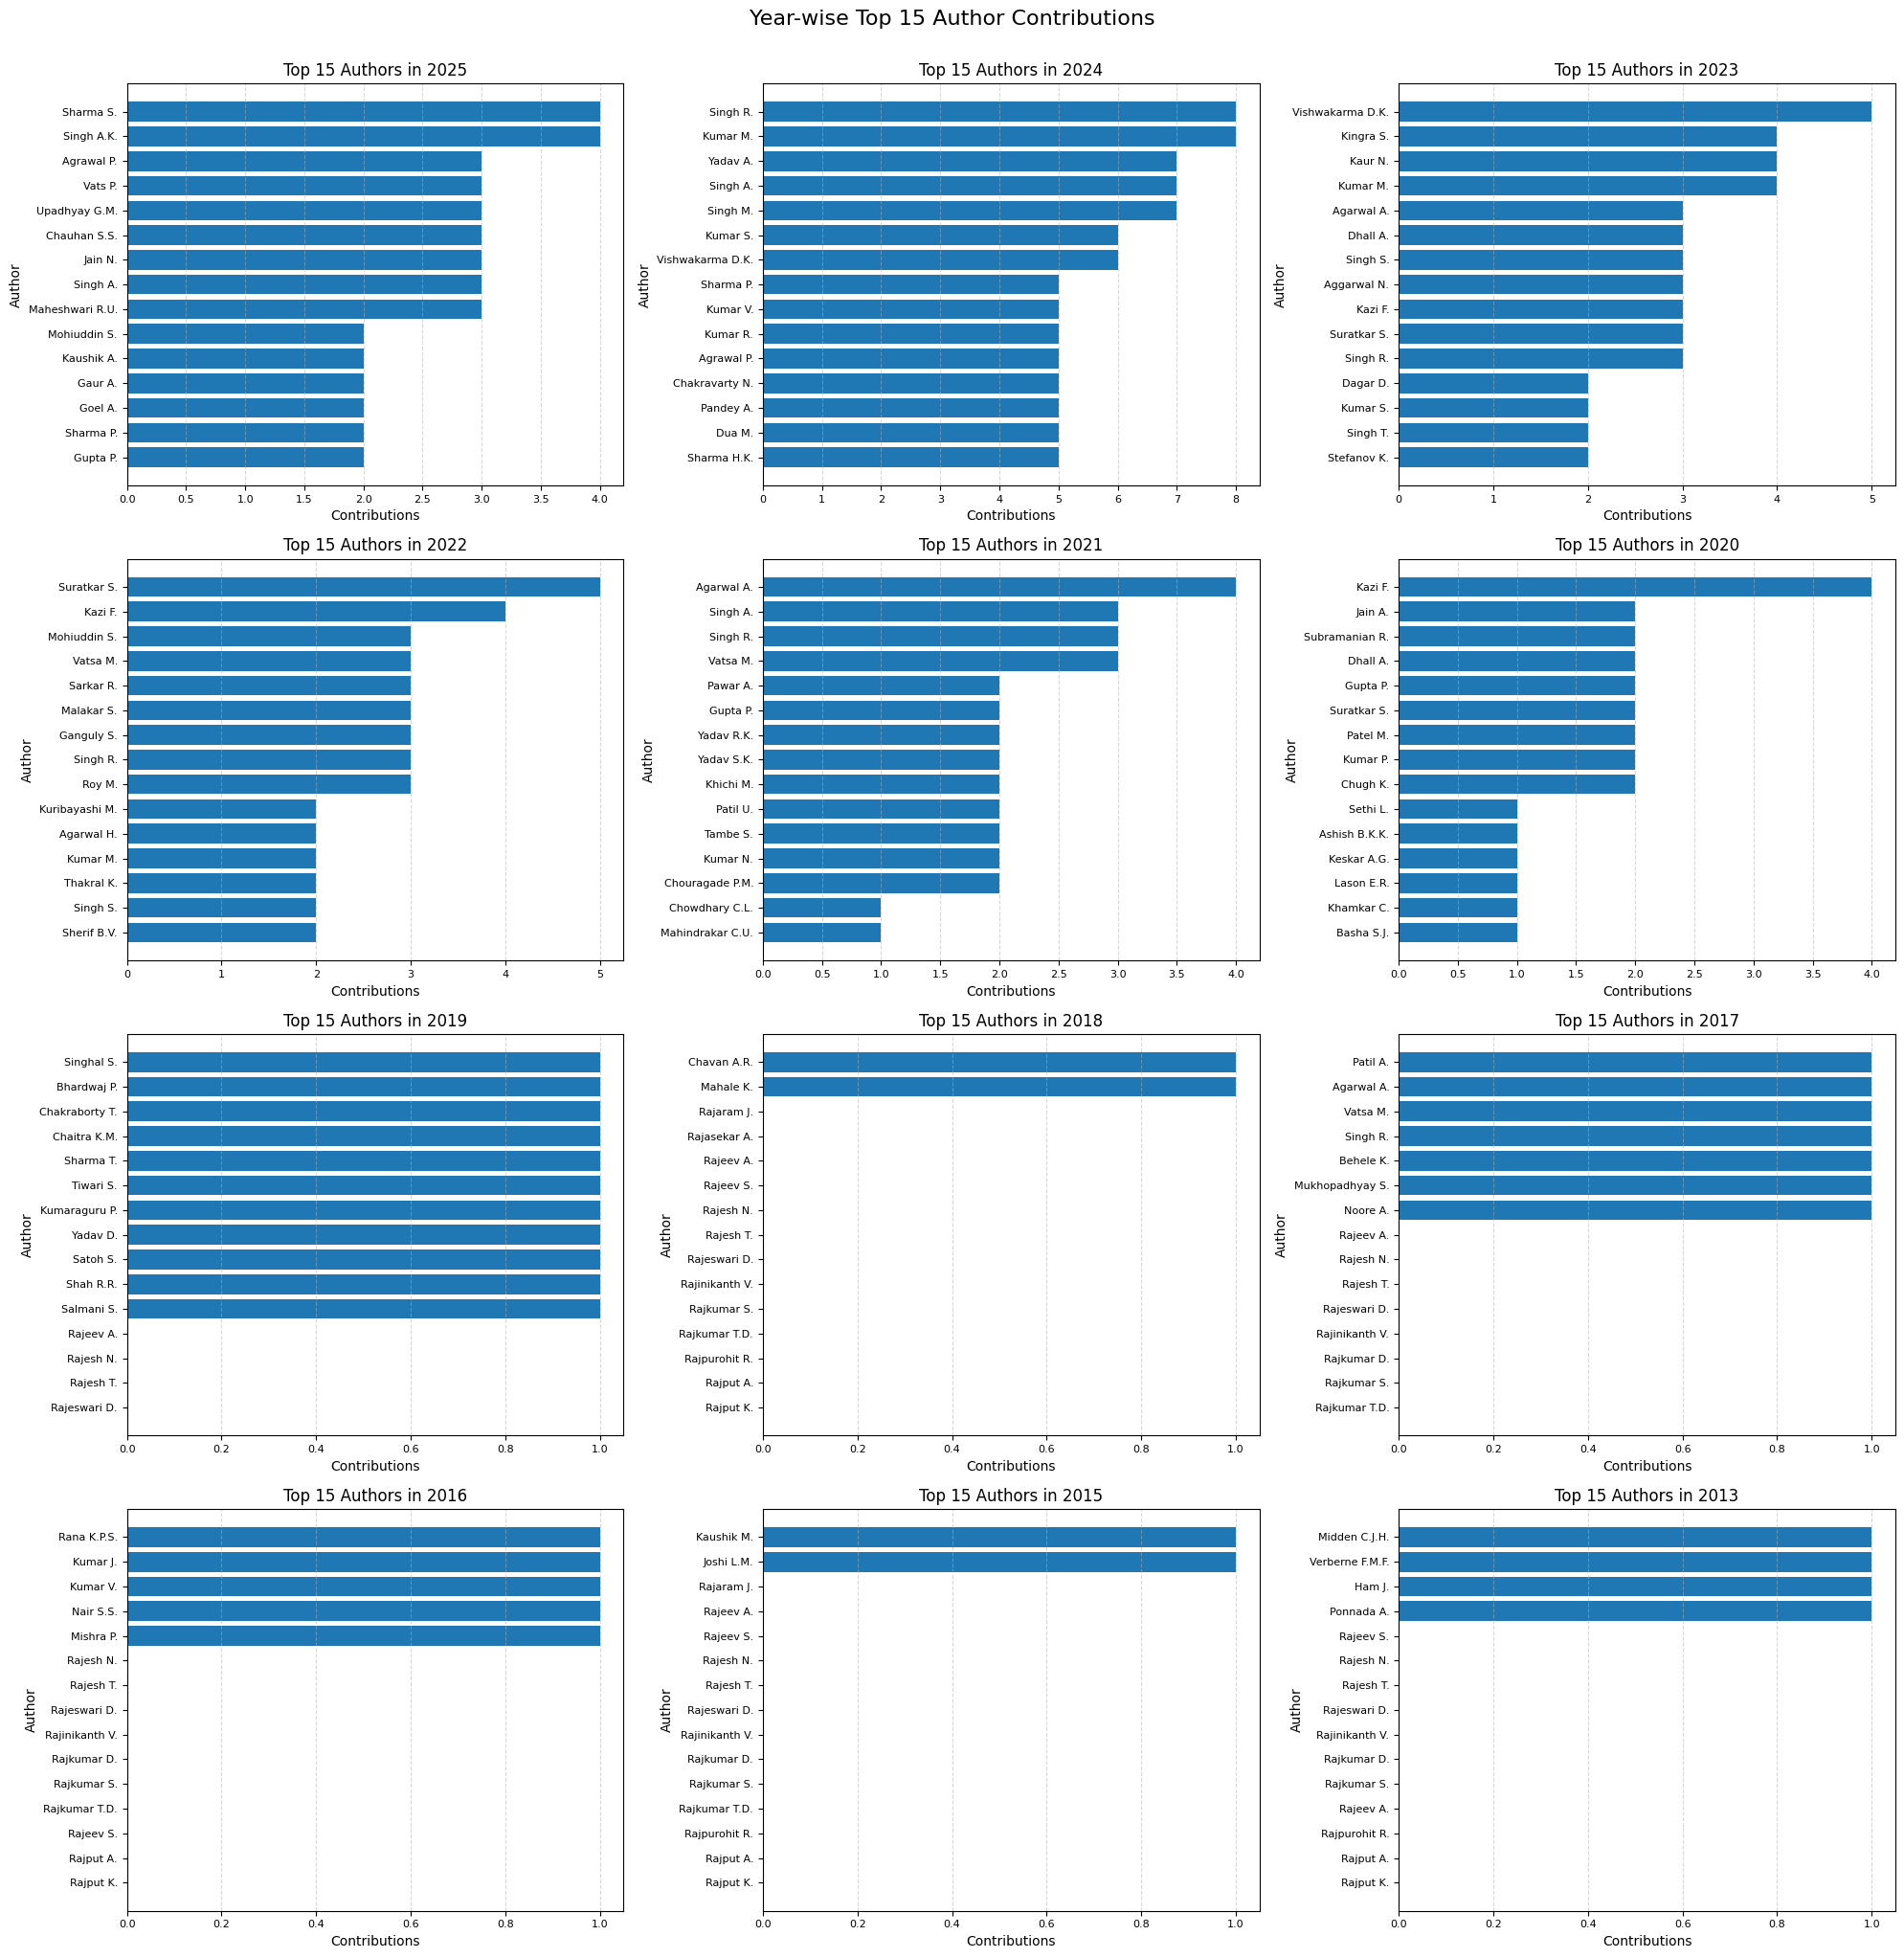

In [ ]:
# @title
# Clean up: ensure Year and Authors are present
deepfake_rp_df = deepfake_rp_df.dropna(subset=["Year", "Authors"])

# Parse authors (assuming they're separated by semicolon)
deepfake_rp_df["Author_List"] = deepfake_rp_df["Authors"].apply(
    lambda x: [a.strip() for a in str(x).split(';') if a.strip()]
)

author_year_data = []

for _, row in deepfake_rp_df.iterrows():
    year = int(row["Year"])
    for author in row["Author_List"]:
        author_year_data.append((year, author))

contrib_df = pd.DataFrame(author_year_data, columns=["Year", "Author"])

# Pivot to get a year-author contribution matrix
year_author_matrix = contrib_df.groupby(["Year", "Author"]).size().unstack(fill_value=0)

years = sorted(year_author_matrix.index, reverse=True)
n_years = len(years)

ncols = 3
nrows = (n_years + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 5 * nrows))
axes = axes.flatten()

for idx, year in enumerate(years):
    top15 = year_author_matrix.loc[year].sort_values(ascending=False).head(15)
    axes[idx].barh(top15.index[::-1], top15.values[::-1])
    axes[idx].set_title(f"Top 15 Authors in {year}", fontsize=12)
    axes[idx].set_xlabel("Contributions")
    axes[idx].set_ylabel("Author")
    axes[idx].tick_params(labelsize=8)
    axes[idx].grid(axis='x', linestyle='--', alpha=0.5)

# Hide unused subplots
for j in range(idx + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle("Year-wise Top 15 Author Contributions", fontsize=16, y=1.02)
plt.show()

In [ ]:
# @title
# top_n = 15
# top_authors = author_df.head(top_n)

# plt.figure(figsize=(12, 6))
# bars = plt.barh(top_authors['Author (ID)'], top_authors['Contributions'], color='skyblue')

# # Invert y-axis to show the top contributor at the top
# plt.gca().invert_yaxis()

# plt.ylabel('Author (with ID)')
# plt.xlabel('Number of Contributions')
# plt.grid(axis='y', linestyle='--', alpha=0.4)
# plt.title(f'Top {top_n} Authors by Contributions')
# plt.tight_layout()
# plt.show()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Total unique values 4
Quartile Counts:
 Quartile
Q4    118
Q1     94
Q2     68
Q3     39
Name: count, dtype: int64


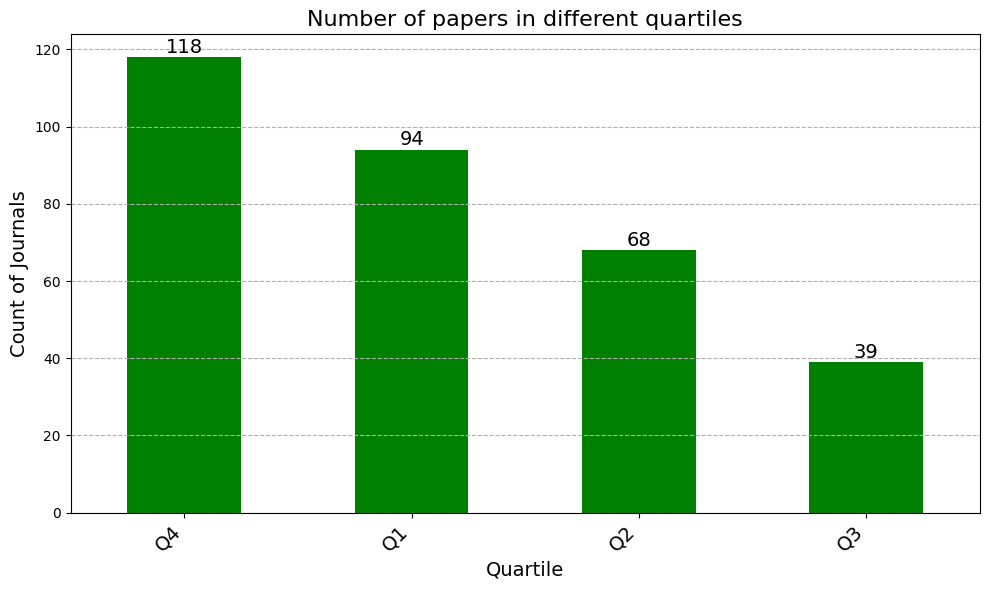

In [ ]:
# @title

filtered_df = deepfake_rp_df[
    deepfake_rp_df['Quartile'].notna() &
    (deepfake_rp_df['Quartile'] != 'NIL') &
    (deepfake_rp_df['Quartile'] != '-')
]

unique_values = filtered_df['Quartile'].nunique()
print("Total unique values", unique_values)

quartile_counts = filtered_df['Quartile'].value_counts()
print("Quartile Counts:\n", quartile_counts)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
quartile_counts.plot(kind='bar', color='green')
for i, value in enumerate(quartile_counts):
    plt.text(i, value + 0.1, str(value), ha='center', va='bottom', fontsize=14)
plt.title('Number of papers in different quartiles', fontsize=16)
plt.xlabel('Quartile',fontsize=14)
plt.ylabel('Count of Journals',fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=1)
plt.tight_layout()
plt.show()


in q1 journals what was the reason of them being in the q1, was it keywords was it foreign colaboration


The h-index is a metric used in research to measure both the productivity and impact of a scientist's published work. It's calculated as the highest number 'h' such that a researcher has 'h' publications that have each been cited at least 'h' times. Essentially, an h-index of 10 means that a researcher has 10 papers, each cited at least 10 times.

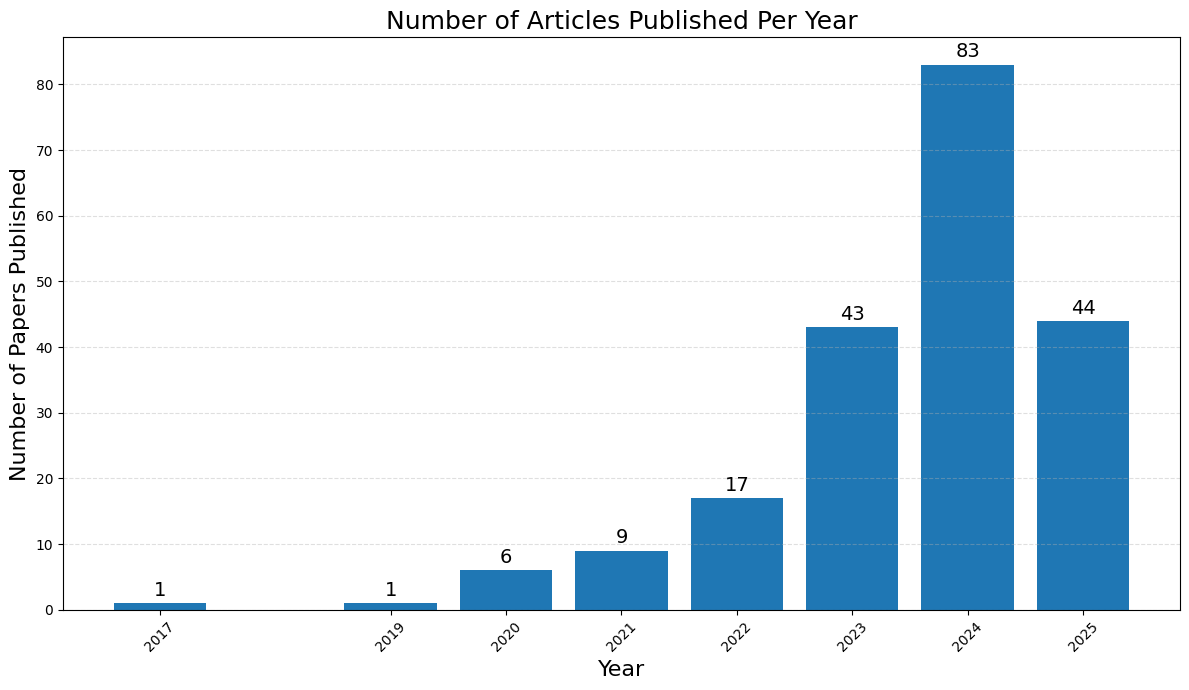

In [ ]:
# @title
articles_df = deepfake_rp_df[deepfake_rp_df['Document Type'] == 'Article']
articles = articles_df.groupby('Year').size().sort_index()
plt.figure(figsize=(12, 7))
bars = plt.bar(articles.index, articles.values)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.5, str(height),
             ha='center', va='bottom', fontsize=14)
plt.xlabel('Year', fontsize=16)
plt.ylabel('Number of Papers Published', fontsize=16)
plt.title('Number of Articles Published Per Year', fontsize=18)
print()
plt.xticks(ticks=articles.index, labels=articles.index, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


<IPython.core.display.Javascript object>

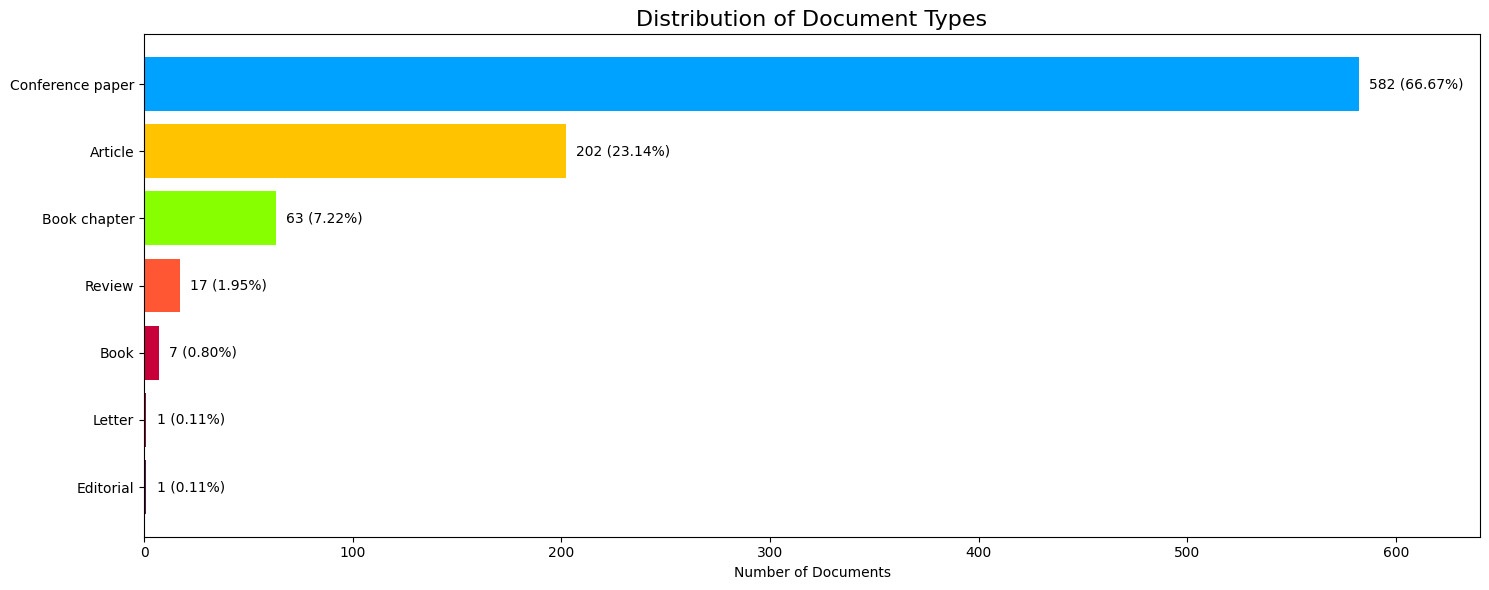

In [ ]:
# @title
doc_df = deepfake_rp_df[deepfake_rp_df['Document Type'].isin(
    ['Article', 'Conference paper', 'Book', 'Book chapter', 'Editorial', 'Letter', 'Review'])]
value_count = doc_df['Document Type'].value_counts()
colors = ['#00a2ff', '#FFC300', '#87ff00', '#FF5733', '#C70039', '#900C3F', '#581845']
plt.figure(figsize=(15, 6))
bars = plt.barh(value_count.index, value_count.values, color=colors)
total = value_count.sum()
for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height()/2,
             f'{width} ({(width / total) * 100:.2f}%)',
             va='center', fontsize=10)
plt.xlim(0, max(value_count.values) * 1.1)
plt.title('Distribution of Document Types', fontsize=16)
plt.xlabel('Number of Documents')
plt.gca().invert_yaxis()  # Highest value at the top
plt.tight_layout()
plt.show()


<IPython.core.display.Javascript object>

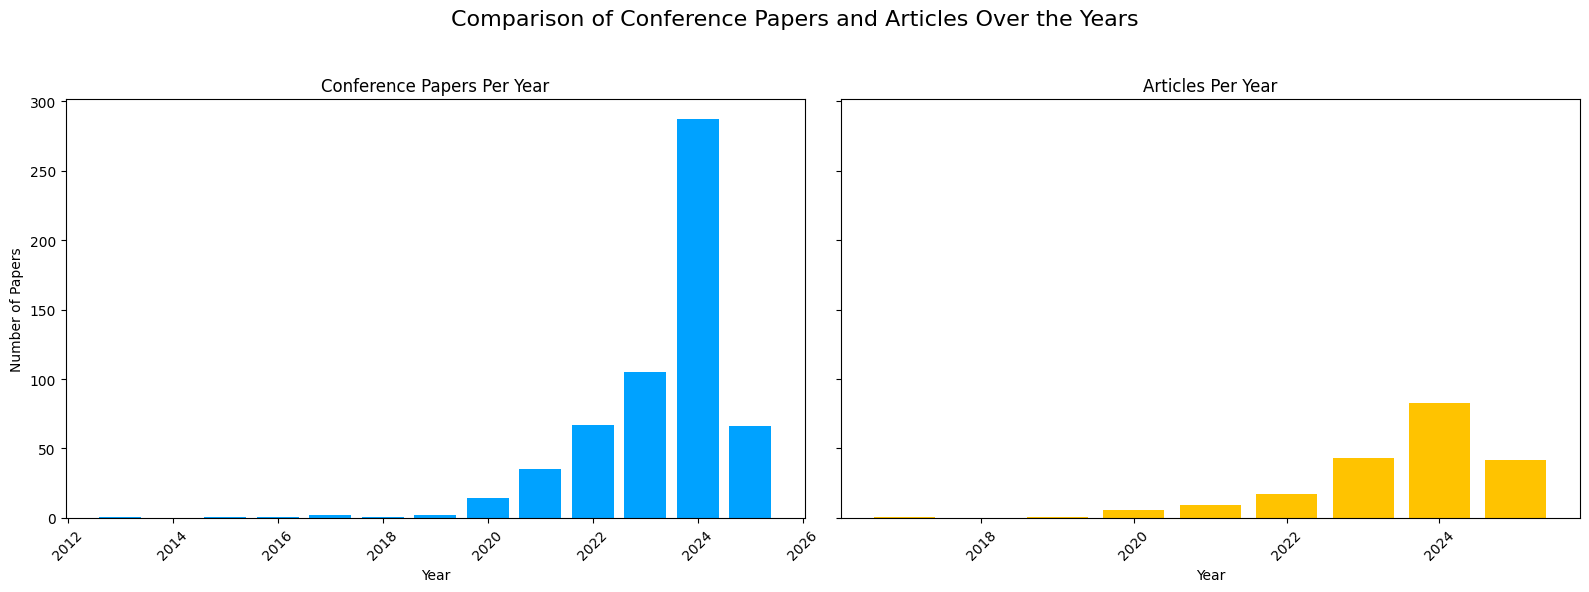

In [ ]:
# @title
# Filter data
conf_df = deepfake_rp_df[deepfake_rp_df['Document Type'] == 'Conference paper']
article_df = deepfake_rp_df[deepfake_rp_df['Document Type'] == 'Article']

# Group by year
conf_paper = conf_df.groupby('Year').size().sort_index()
article_paper = article_df.groupby('Year').size().sort_index()

# Plotting subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Conference Paper subplot
axes[0].bar(conf_paper.index, conf_paper.values, color='#00a2ff')
axes[0].set_title('Conference Papers Per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Papers')
axes[0].tick_params(axis='x', rotation=45)

# Article subplot
axes[1].bar(article_paper.index, article_paper.values, color='#FFC300')
axes[1].set_title('Articles Per Year')
axes[1].set_xlabel('Year')
axes[1].tick_params(axis='x', rotation=45)

# Layout and display
plt.suptitle('Comparison of Conference Papers and Articles Over the Years', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [ ]:
# @title
#removing outliers using the IQR(inter quartile range method )
df = deepfake_rp_df
# df = df[df['Document Type'] == 'Article']
df = df.dropna(subset=['Cited by'])
Q1 = df['Cited by'].quantile(0.25)
Q3 = df['Cited by'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['Cited by'] >= lower_bound) & (df['Cited by'] <= upper_bound)]
df.shape

<IPython.core.display.Javascript object>

(756, 48)

In [ ]:
# @title
df = df[
    deepfake_rp_df['Author Keywords'].notna() | deepfake_rp_df['Index Keywords'].notna()
]
df.shape
df['Cited by'].max()

<IPython.core.display.Javascript object>

<ipython-input-31-1bedbdd26723>:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df = df[


10

<IPython.core.display.Javascript object>


Training Random Forest...

Random Forest Detailed Metrics:
Mean Squared Error (MSE): 1.03
Root Mean Squared Error (RMSE): 1.02
Mean Absolute Error (MAE): 0.67
R-squared Score: 0.80


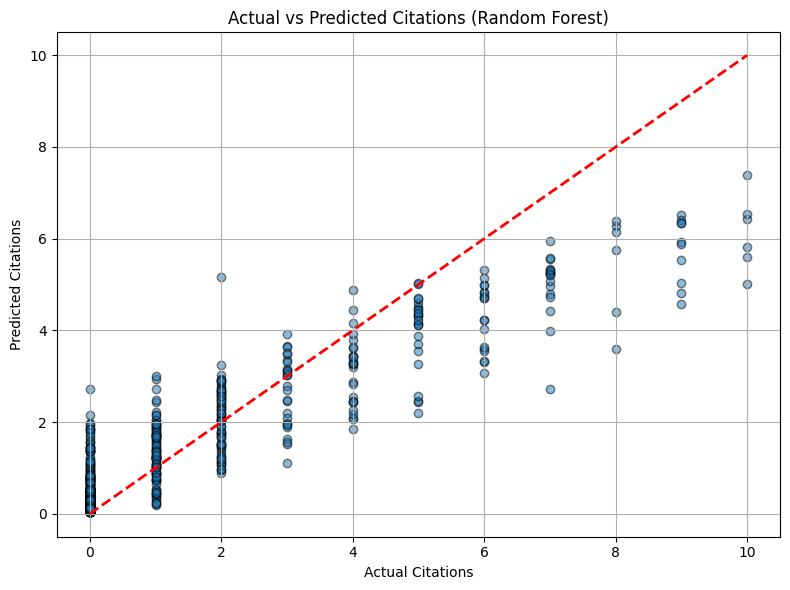

In [ ]:
# @title
def clean_keyword(keyword):
    keyword = keyword.lower().strip()
    keyword = re.sub(r'[^\w\s]', '', keyword)
    keyword = re.sub(r'\s+', ' ', keyword)
    return keyword

def process_keywords(keywords_series):
    all_keywords = []
    for keywords in keywords_series.dropna():
        keyword_list = [clean_keyword(k) for k in keywords.split(';')]
        all_keywords.extend(keyword_list)
    keyword_counter = Counter(all_keywords)
    top_keywords = [word for word, count in keyword_counter.most_common(20)]
    keyword_features = pd.DataFrame(index=keywords_series.index)
    for keyword in top_keywords:
        keyword_features[f'has_{keyword.replace(" ", "_")}'] = keywords_series.str.contains(
            keyword, case=False, na=False, regex=False
        ).astype(int)
    return keyword_features

def prepare_features(df):
    df_processed = df.copy()
    df_processed['author_count'] = df_processed['Authors'].str.count(';') + 1
    df_processed['Year'] = pd.to_numeric(df_processed['Year'], errors='coerce')
    df_processed['reference_count'] = df_processed['References'].str.count(';') + 1
    df_processed['reference_count'] = df_processed['reference_count'].fillna(0)
    df_processed['Page count'] = pd.to_numeric(df_processed['Page count'], errors='coerce')
    df_processed['is_open_access'] = df_processed['Open Access'].notna().astype(int)
    author_keyword_features = process_keywords(df_processed['Author Keywords'])
    index_keyword_features = process_keywords(df_processed['Index Keywords'])

    tfidf = TfidfVectorizer(max_features=20, stop_words='english')
    author_keywords_clean = df_processed['Author Keywords'].fillna('').apply(
        lambda x: ' '.join([clean_keyword(k) for k in x.split(';')])
    )
    author_keywords_tfidf = tfidf.fit_transform(author_keywords_clean)
    index_keywords_clean = df_processed['Index Keywords'].fillna('').apply(
        lambda x: ' '.join([clean_keyword(k) for k in x.split(';')])
    )
    index_keywords_tfidf = tfidf.fit_transform(index_keywords_clean)

    author_keywords_tfidf_df = pd.DataFrame(
        author_keywords_tfidf.toarray(),
        columns=[f'author_tfidf_{i}' for i in range(author_keywords_tfidf.shape[1])],
        index=df_processed.index
    )
    index_keywords_tfidf_df = pd.DataFrame(
        index_keywords_tfidf.toarray(),
        columns=[f'index_tfidf_{i}' for i in range(index_keywords_tfidf.shape[1])],
        index=df_processed.index
    )

    basic_features = ['Year', 'author_count', 'Page count', 'reference_count', 'is_open_access']
    for col in basic_features:
        if df_processed[col].isnull().any():
            df_processed[col] = df_processed[col].fillna(df_processed[col].median())

    X_basic = df_processed[basic_features]
    X = pd.concat([
        X_basic,
        author_keyword_features,
        index_keyword_features,
        author_keywords_tfidf_df,
        index_keywords_tfidf_df
    ], axis=1)
    y = df_processed['Cited by']
    # print("\nFeature Statistics:")
    # print(X.describe())
    # print("\nTop Author Keywords:")
    # print(author_keyword_features.columns.tolist())
    # print("\nTop Index Keywords:")
    # print(index_keyword_features.columns.tolist())
    return X, y

def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name} Detailed Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"R-squared Score: {r2:.2f}")

    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
    }

def train_and_evaluate_models(X, y):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    )

    print("\nTraining Random Forest...")
    # cv_scores = cross_val_score(model, X_scaled, y, cv=kf, scoring='r2')
    # print(f"\nCross-validation R2 scores: {cv_scores}")
    # print(f"Mean CV R2 score: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

    model.fit(X_scaled, y)
    y_pred = model.predict(X_scaled)
    metrics = evaluate_model(y, y_pred, 'Random Forest')

    return {
        'Random Forest': {
            'model': model,
            'scaler': scaler,
            'metrics': metrics
        }
    }

def plot_actual_vs_predicted(y_true, y_pred, model_name='Model'):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, y_pred, alpha=0.5, edgecolor='k')
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], '--r', linewidth=2)
    plt.xlabel('Actual Citations')
    plt.ylabel('Predicted Citations')
    plt.title(f'Actual vs Predicted Citations ({model_name})')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def main():
    X, y = prepare_features(df)
    results = train_and_evaluate_models(X, y)

    joblib.dump(results['Random Forest']['model'], 'best_model.joblib')
    joblib.dump(results['Random Forest']['scaler'], 'scaler.joblib')
    plot_actual_vs_predicted(y, results['Random Forest']['model'].predict(results['Random Forest']['scaler'].transform(X)), model_name='Random Forest')

if __name__ == "__main__":
    main()

In [ ]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# --- Keyword cleaning and feature processing ---
def clean_keyword(keyword):
    keyword = keyword.lower().strip()
    keyword = re.sub(r'[^\w\s]', '', keyword)
    keyword = re.sub(r'\s+', ' ', keyword)
    return keyword

def process_keywords(keywords_series):
    all_keywords = []
    for keywords in keywords_series.dropna():
        keyword_list = [clean_keyword(k) for k in keywords.split(';')]
        all_keywords.extend(keyword_list)
    keyword_counter = Counter(all_keywords)
    top_keywords = [word for word, count in keyword_counter.most_common(20)]
    keyword_features = pd.DataFrame(index=keywords_series.index)
    for keyword in top_keywords:
        keyword_features[f'has_{keyword.replace(" ", "_")}'] = keywords_series.str.contains(
            keyword, case=False, na=False, regex=False
        ).astype(int)
    return keyword_features

# --- Feature preparation ---
def prepare_features(df):
    df_processed = df.copy()
    df_processed['author_count'] = df_processed['Authors'].str.count(';') + 1
    df_processed['Year'] = pd.to_numeric(df_processed['Year'], errors='coerce')
    df_processed['reference_count'] = df_processed['References'].str.count(';') + 1
    df_processed['reference_count'] = df_processed['reference_count'].fillna(0)
    df_processed['Page count'] = pd.to_numeric(df_processed['Page count'], errors='coerce')
    df_processed['is_open_access'] = df_processed['Open Access'].notna().astype(int)

    author_keyword_features = process_keywords(df_processed['Author Keywords'])
    index_keyword_features = process_keywords(df_processed['Index Keywords'])

    tfidf = TfidfVectorizer(max_features=50, stop_words='english')  # increased max_features
    author_keywords_clean = df_processed['Author Keywords'].fillna('').apply(
        lambda x: ' '.join([clean_keyword(k) for k in x.split(';')])
    )
    author_keywords_tfidf = tfidf.fit_transform(author_keywords_clean)
    index_keywords_clean = df_processed['Index Keywords'].fillna('').apply(
        lambda x: ' '.join([clean_keyword(k) for k in x.split(';')])
    )
    index_keywords_tfidf = tfidf.fit_transform(index_keywords_clean)

    author_keywords_tfidf_df = pd.DataFrame(
        author_keywords_tfidf.toarray(),
        columns=[f'author_tfidf_{i}' for i in range(author_keywords_tfidf.shape[1])],
        index=df_processed.index
    )
    index_keywords_tfidf_df = pd.DataFrame(
        index_keywords_tfidf.toarray(),
        columns=[f'index_tfidf_{i}' for i in range(index_keywords_tfidf.shape[1])],
        index=df_processed.index
    )

    basic_features = ['Year', 'author_count', 'Page count', 'reference_count', 'is_open_access']
    for col in basic_features:
        if df_processed[col].isnull().any():
            df_processed[col] = df_processed[col].fillna(df_processed[col].median())

    X_basic = df_processed[basic_features]
    X = pd.concat([
        X_basic,
        author_keyword_features,
        index_keyword_features,
        author_keywords_tfidf_df,
        index_keywords_tfidf_df
    ], axis=1)

    y = pd.to_numeric(df_processed['Cited by'], errors='coerce').fillna(0)
    y = np.log1p(y)  # log-transform to reduce skewness
    return X, y

# --- Model evaluation ---
def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name} Detailed Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"R-squared Score: {r2:.2f}")

    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
    }

# --- Train model using Grid Search ---
def train_with_grid_search(X, y):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }

    model = RandomForestRegressor(random_state=42)

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        scoring='r2',
        verbose=2,
        n_jobs=-1
    )

    print("\nRunning Grid Search...")
    grid_search.fit(X_scaled, y)

    best_model = grid_search.best_estimator_
    print("\nBest Parameters Found:", grid_search.best_params_)

    y_pred = best_model.predict(X_scaled)
    metrics = evaluate_model(y, y_pred, 'Random Forest (Tuned)')

    return {
        'model': best_model,
        'scaler': scaler,
        'metrics': metrics
    }

# --- Plotting ---
def plot_actual_vs_predicted(y_true, y_pred_log, model_name='Model'):
    y_true_exp = np.expm1(y_true)
    y_pred_exp = np.expm1(y_pred_log)

    plt.figure(figsize=(8, 6))
    plt.scatter(y_true_exp, y_pred_exp, alpha=0.5, edgecolor='k')
    plt.plot([y_true_exp.min(), y_true_exp.max()], [y_true_exp.min(), y_true_exp.max()], '--r', linewidth=2)
    plt.xlabel('Actual Citations')
    plt.ylabel('Predicted Citations')
    plt.title(f'Actual vs Predicted Citations ({model_name})')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- Main ---
def main():
    # Ensure df is already loaded before calling this
    df = pd.read_csv("/content/drive/MyDrive/DEEPFAKE877.csv")
    X, y = prepare_features(df)
    result = train_with_grid_search(X, y)

    # Save model and scaler
    joblib.dump(result['model'], 'best_model.joblib')
    joblib.dump(result['scaler'], 'scaler.joblib')

    # Plot actual vs predicted
    X_scaled = result['scaler'].transform(X)
    y_pred_log = result['model'].predict(X_scaled)
    plot_actual_vs_predicted(y, y_pred_log, model_name='Random Forest (Tuned)')

if __name__ == "__main__":
    main()


Running Grid Search...
Fitting 5 folds for each of 108 candidates, totalling 540 fits


TF-IDF stands for Term Frequency–Inverse Document Frequency. It’s a numerical statistic used in information retrieval and text mining to evaluate how important a word is to a document in a collection or corpus.
* TF (Term Frequency) – how often a word appears in a document.

$$
TF(t, d) = \frac{\text{Number of times term } t \text{ appears in document } d}{\text{Total number of terms in document } d}
$$

IDF (Inverse Document Frequency) – how rare a word is across all documents


# Appendix

In [ ]:
# @title
import pycountry
import re
country_names = [country.name for country in pycountry.countries]
def extract_country_from_affiliation(aff):
    if pd.isna(aff):
        return None

    # Split by semicolon if present, take last segment
    parts = aff.split(';')
    last_part = parts[-1] if parts else aff

    # Extract after the last comma
    country_hint = last_part.strip().split(',')[-1].strip()

    # Match against known countries
    for country in country_names:
        if country.lower() == country_hint.lower():
            return country
    return None

# Apply function
df['Country'] = df['Affiliations'].apply(extract_country_from_affiliation)

# Count countries
country_counts = df['Country'].value_counts().reset_index()
country_counts.columns = ['Country', 'Count']

# Display as table
print(country_counts)

<IPython.core.display.Javascript object>

                 Country  Count
0                  India    642
1          United States     17
2           Saudi Arabia      3
3         United Kingdom      3
4                 Canada      3
5                  Japan      3
6              Australia      2
7   United Arab Emirates      2
8                  Italy      2
9                 Jordan      2
10                France      2
11                 China      1
12              Malaysia      1
13               Romania      1
14               Ireland      1
15                Israel      1
16               Nigeria      1
17              Maldives      1
18               Estonia      1
19              Ethiopia      1
20                 Egypt      1
21               Lebanon      1
22             Singapore      1
23                 Yemen      1
24           Switzerland      1


In [ ]:
pip install pycountry

<IPython.core.display.Javascript object>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 81.2 MB/s eta 0:00:00


In [ ]:
# @title
country_df = pd.read_csv('/content/drive/MyDrive/Country.csv')
countries_to_remove = ['Computer Science and Engineering Department','TCG Centres for Research and Education in Science and Technology']
filtered_df = country_df[~country_df['Country'].isin(countries_to_remove)]
country_counts = filtered_df['Country'].value_counts()
print(country_counts)

<IPython.core.display.Javascript object>

Country
India                   1494
United States             43
Saudi Arabia              19
United Arab Emirates      15
Australia                 12
France                    12
Japan                      8
Malaysia                   8
Canada                     7
Singapore                  7
United Kingdom             7
Jordan                     7
China                      7
Finland                    6
Ireland                    6
Taiwan                     6
South Korea                5
Norway                     5
Iraq                       5
Switzerland                4
Oman                       4
Italy                      4
Egypt                      4
Czech Republic             4
South Africa               4
Pakistan                   3
Yemen                      2
Chile                      2
Uzbekistan                 2
Bangladesh                 2
Russian Federation         2
Mexico                     2
Lebanon                    2
Nepal                      1
Philip

<IPython.core.display.Javascript object>

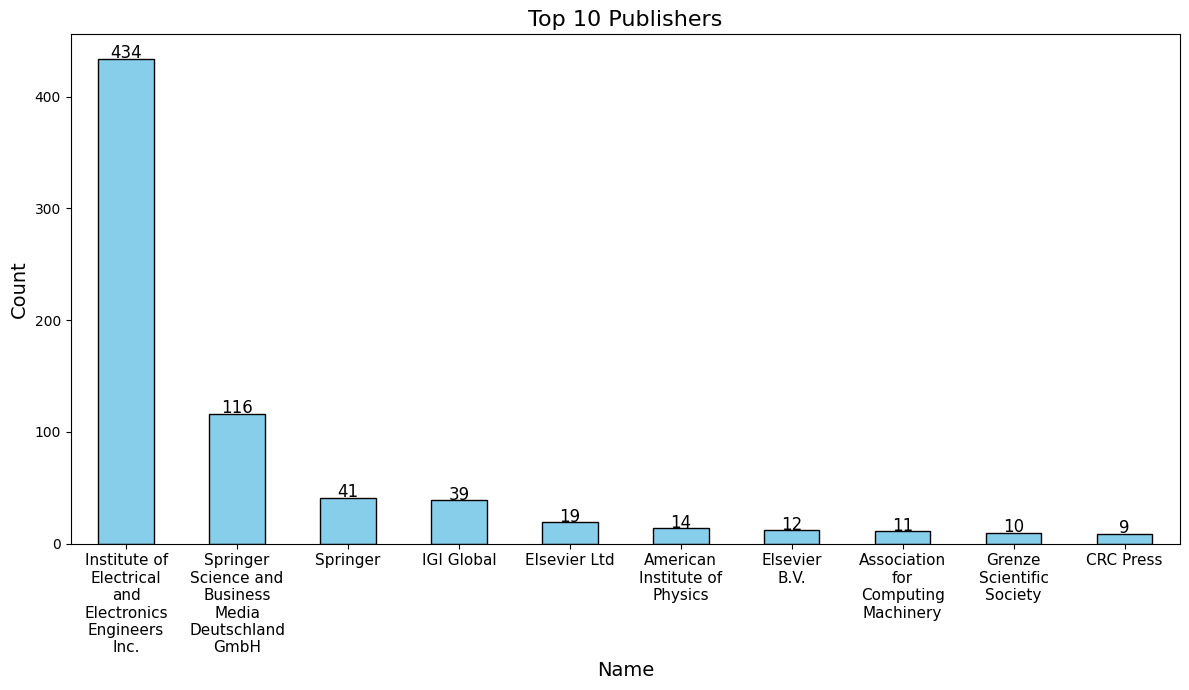

In [ ]:
# @title
import textwrap
publisher_column = 'Publisher'

publisher_counts = deepfake_rp_df[publisher_column].value_counts().head(10)

plt.figure(figsize=(12, 7))
bars = publisher_counts.plot(kind='bar', color='skyblue', edgecolor='black')

for bar in bars.patches:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{int(bar.get_height())}",
        ha='center',
        fontsize=12,)

plt.title('Top 10 Publishers', fontsize=16)
plt.xlabel('Name', fontsize=14)
plt.ylabel('Count', fontsize=14)

#textwrap
max_label_width = 12  # maximum characters per line
wrapped_labels = [
    '\n'.join(textwrap.wrap(label, max_label_width)) for label in publisher_counts.index
]

plt.xticks(ticks=range(len(publisher_counts)), labels=wrapped_labels, rotation=0, ha='center', fontsize=11)

plt.tight_layout()
plt.show()


<IPython.core.display.Javascript object>

Correlation between SJR and H-Index: 0.43


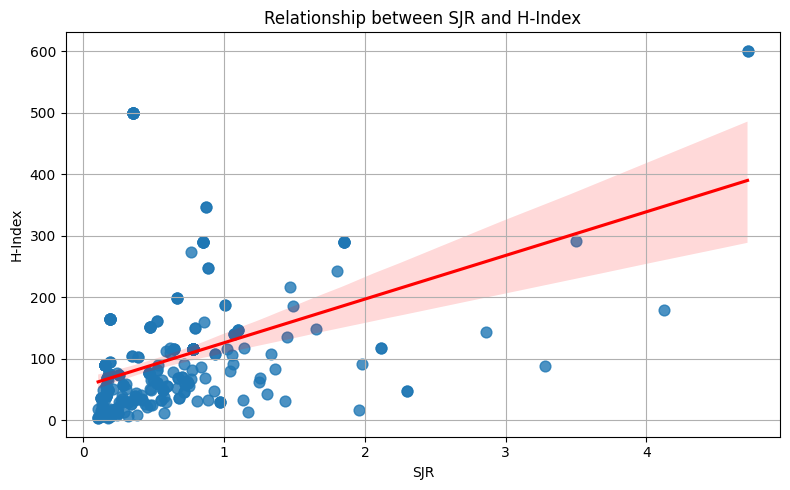

In [ ]:
# @title
df = pd.read_csv("/content/drive/MyDrive/DEEPFAKE877.csv")
# Step 2: Clean the data
df.replace(['NIL', 'DIS', '-'], pd.NA, inplace=True)
df.dropna(subset=['SJR', 'H-Index'], inplace=True)

# Step 3: Convert to numeric types
df['SJR'] = df['SJR'].astype(float)
df['H-Index'] = df['H-Index'].astype(int)

# Step 4: Calculate correlation
correlation = df['SJR'].corr(df['H-Index'])
print(f"Correlation between SJR and H-Index: {correlation:.2f}")

# Step 5: Visualize
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='SJR', y='H-Index', scatter_kws={'s': 60}, line_kws={"color": "red"})
plt.title('Relationship between SJR and H-Index')
plt.xlabel('SJR')
plt.ylabel('H-Index')
plt.grid(True)
plt.tight_layout()
plt.show()

<IPython.core.display.Javascript object>

<ipython-input-40-7afa1bf63b36>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[numeric_columns] = numeric_imputer.fit_transform(df[numeric_columns])
<ipython-input-40-7afa1bf63b36>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[text_columns] = text_imputer.fit_transform(df[text_columns])


R² Score: 0.5319
Mean Absolute Error (MAE): 0.5924
Mean Squared Error (MSE): 0.7014
Predicted Cited by: 3.20


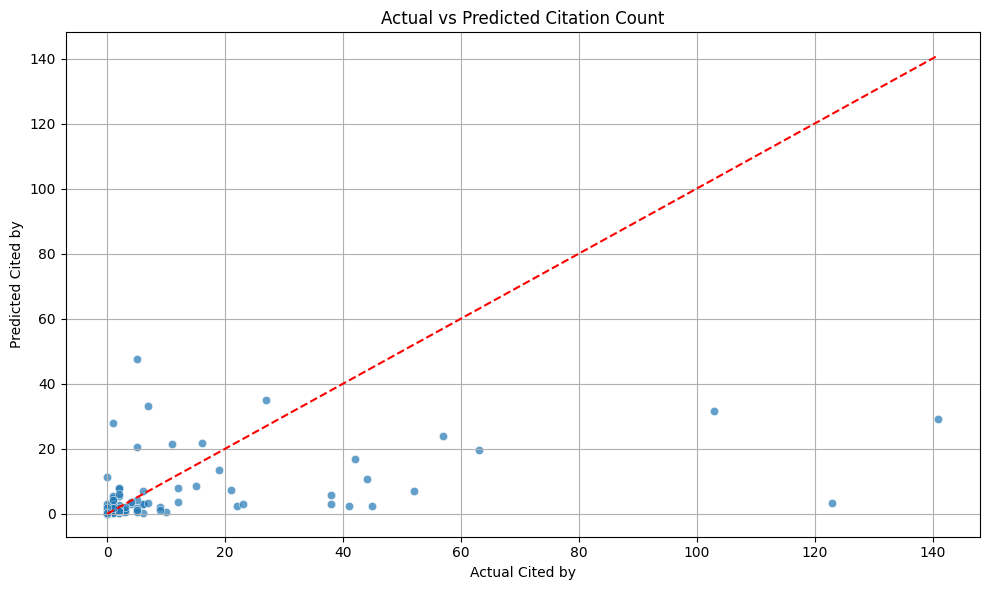

In [ ]:
# @title
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

df = deepfake_rp_df[['Year', 'Affiliations', 'Author Keywords', 'Index Keywords', 'Document Type', 'Open Access', 'Cited by']]

# Handle missing values in numeric columns (Year) using SimpleImputer with strategy 'mean'
numeric_columns = ['Year']
numeric_imputer = SimpleImputer(strategy='mean')
df[numeric_columns] = numeric_imputer.fit_transform(df[numeric_columns])

# Handle missing values in text columns using SimpleImputer with strategy 'most_frequent'
text_columns = ['Affiliations', 'Author Keywords', 'Index Keywords', 'Document Type', 'Open Access']
text_imputer = SimpleImputer(strategy='most_frequent')
df[text_columns] = text_imputer.fit_transform(df[text_columns])

# Apply log transformation to 'Cited by' to handle skewness (log(1 + Cited by) handles 0 values)
y = np.log1p(df['Cited by'])

# Drop the target column from the feature set
X = df.drop(columns=['Cited by'])

# Define a custom transformer to reshape the 'Year' column into a 2D array
def passthrough(X):
    return np.array(X).reshape(-1, 1)  # Ensure 'Year' column is in 2D format

# Preprocessing pipeline for text features using TF-IDF Vectorization
text_pipeline = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(max_features=1000, stop_words='english'))
])

# Column transformer for numeric and text features
preprocessor = ColumnTransformer(
    transformers=[
        ('text', text_pipeline, 'Affiliations'),
        ('text2', text_pipeline, 'Author Keywords'),
        ('text3', text_pipeline, 'Index Keywords'),
        ('text4', text_pipeline, 'Document Type'),
        ('text5', text_pipeline, 'Open Access'),
        ('num', FunctionTransformer(passthrough), 'Year')
    ])

# Create a pipeline that applies preprocessing and then trains the model
from xgboost import XGBRegressor
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
])



# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Predict the citations on the test set
y_pred = model.predict(X_test)

# Evaluate the model using R², MAE, and MSE
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f'R² Score: {r2:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Squared Error (MSE): {mse:.4f}')

# Hardcoded data for prediction (for example, a new entry)
new_data = pd.DataFrame({
    'Year': [2023],
    'Affiliations': ['Department of Computer Science, Aligarh Muslim University, Aligarh, India; Department of Electrical and Communication Engineering, Okayama University, Okayama, Japan; College of Computer and Information Technology, China Three Gorges University, Yichang, China; Department of Computer Application, Integral University, Lucknow, India'],
    'Author Keywords': ['CNNs; Deep learning; DeepFake; GANs'],
    'Index Keywords': [' Deep neural networks; Face recognition; Fake detection; Learning algorithms; CNN; Deep learning; Deepfake; Detection methods; Face features; Face images; GAN; Human face image; Multimedia information; TV channels; Surveys'],
    'Document Type': ['Review'],
    'Open Access': ['Yes']
})

# Handle missing values in the hardcoded data
new_data[text_columns] = text_imputer.transform(new_data[text_columns])
new_data[numeric_columns] = numeric_imputer.transform(new_data[numeric_columns])

# Predict the citation count for the hardcoded data
y_pred_new = model.predict(new_data)

# Inverse the log transformation to get the predicted citation count
predicted_cited_by = np.expm1(y_pred_new)

print(f'Predicted Cited by: {predicted_cited_by[0]:.2f}')


import matplotlib.pyplot as plt
import seaborn as sns

# Inverse log transformation for actual and predicted citation counts
actual_citations = np.expm1(y_test)
predicted_citations = np.expm1(y_pred)

# Create a DataFrame for visualization
results_df = pd.DataFrame({
    'Actual Cited by': actual_citations,
    'Predicted Cited by': predicted_citations
})

# Plot Actual vs Predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Actual Cited by', y='Predicted Cited by', data=results_df, alpha=0.7)
plt.plot([actual_citations.min(), actual_citations.max()], [actual_citations.min(), actual_citations.max()], 'r--')
plt.xlabel('Actual Cited by')
plt.ylabel('Predicted Cited by')
plt.title('Actual vs Predicted Citation Count')
plt.grid(True)
plt.tight_layout()
plt.show()



In [ ]:
# @title
# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split
# from sklearn.impute import SimpleImputer
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.pipeline import Pipeline
# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import FunctionTransformer
# from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# from xgboost import XGBRegressor
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Select all relevant columns
# df = deepfake_rp_df[['Year', 'Affiliations', 'Author Keywords', 'Index Keywords',
#                      'Document Type', 'Open Access', 'Quartile', 'Source title',
#                      'H-Index', 'Author full names', 'Title', 'Cited by']]

# # Convert 'NIL' to np.nan in H-Index and make it numeric
# df['H-Index'] = df['H-Index'].replace('NIL', np.nan)
# df['H-Index'] = pd.to_numeric(df['H-Index'], errors='coerce')

# # Define column types
# numeric_columns = ['Year', 'H-Index']
# text_columns = ['Affiliations', 'Author Keywords', 'Index Keywords', 'Document Type',
#                 'Open Access', 'Quartile', 'Source title', 'Author full names', 'Title']

# # Handle missing values
# numeric_imputer = SimpleImputer(strategy='mean')
# text_imputer = SimpleImputer(strategy='most_frequent')

# df[numeric_columns] = numeric_imputer.fit_transform(df[numeric_columns])
# df[text_columns] = text_imputer.fit_transform(df[text_columns])

# # Target transformation
# y = np.log1p(df['Cited by'])
# X = df.drop(columns=['Cited by'])

# # Define passthrough for numeric
# def passthrough(X):
#     return np.array(X).reshape(-1, 1)

# # Text pipeline
# text_pipeline = Pipeline(steps=[
#     ('tfidf', TfidfVectorizer(max_features=500, stop_words='english'))
# ])

# # ColumnTransformer with all text and numeric columns
# preprocessor = ColumnTransformer(transformers=[
#     ('affil', text_pipeline, 'Affiliations'),
#     ('auth_kw', text_pipeline, 'Author Keywords'),
#     ('idx_kw', text_pipeline, 'Index Keywords'),
#     ('doc_type', text_pipeline, 'Document Type'),
#     ('open', text_pipeline, 'Open Access'),
#     ('quartile', text_pipeline, 'Quartile'),
#     ('source', text_pipeline, 'Source title'),
#     ('author', text_pipeline, 'Author Name'),
#     ('title', text_pipeline, 'Title'),
#     ('year', FunctionTransformer(passthrough), 'Year'),
#     ('hindex', FunctionTransformer(passthrough), 'H-Index'),
# ])

# # Final pipeline with XGBoost
# model = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('regressor', XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
# ])

# # Train-test split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69)

# # Train
# model.fit(X_train, y_train)

# # Predict and evaluate
# y_pred = model.predict(X_test)
# r2 = r2_score(y_test, y_pred)
# mae = mean_absolute_error(y_test, y_pred)
# mse = mean_squared_error(y_test, y_pred)

# print(f'R² Score: {r2:.4f}')
# print(f'MAE: {mae:.4f}')
# print(f'MSE: {mse:.4f}')

# # Visualization
# actual_citations = np.expm1(y_test)
# predicted_citations = np.expm1(y_pred)

# results_df = pd.DataFrame({
#     'Actual Cited by': actual_citations,
#     'Predicted Cited by': predicted_citations
# })

# plt.figure(figsize=(10, 6))
# sns.scatterplot(x='Actual Cited by', y='Predicted Cited by', data=results_df, alpha=0.7)
# plt.plot([actual_citations.min(), actual_citations.max()],
#          [actual_citations.min(), actual_citations.max()], 'r--')
# plt.xlabel('Actual Cited by')
# plt.ylabel('Predicted Cited by')
# plt.title('Actual vs Predicted Citation Count (Enhanced Features)')
# plt.grid(True)
# plt.tight_layout()
# plt.show()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

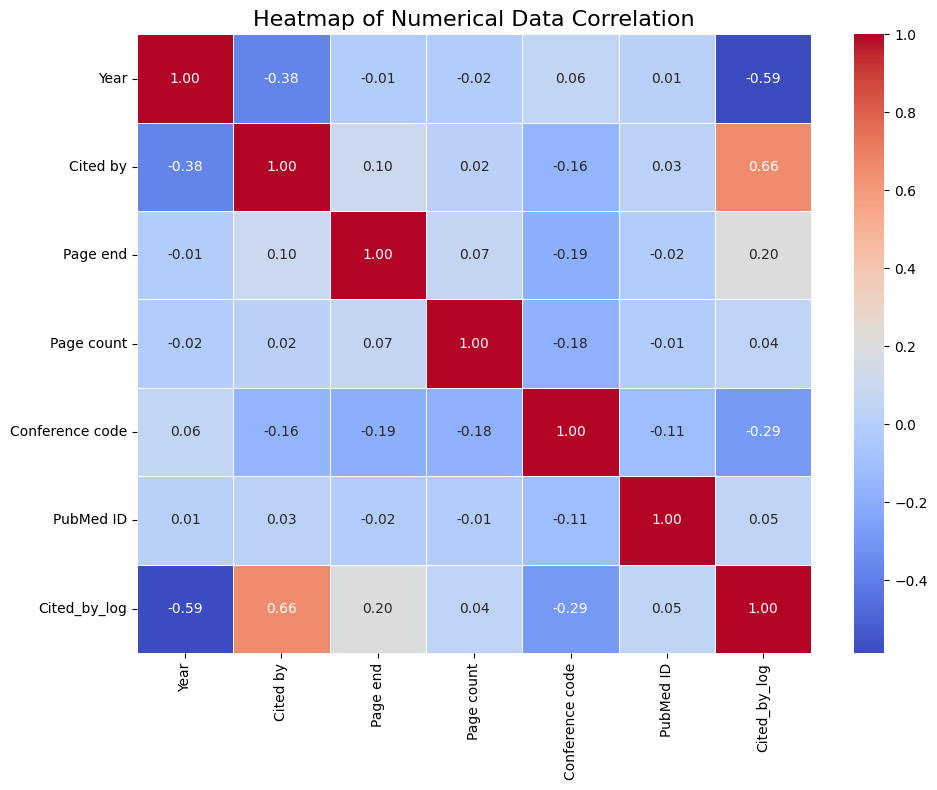

In [ ]:
# @title
numerical_df = deepfake_rp_df.select_dtypes(include=['int64', 'float64'])

# Optional: handle NaNs (fill or drop)
numerical_df = numerical_df.fillna(0)

# Compute correlation matrix (optional, based on what heatmap you want)
corr = numerical_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap of Numerical Data Correlation', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# @title
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, explained_variance_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
import re
import joblib

def clean_keyword(keyword):
    keyword = keyword.lower().strip()
    keyword = re.sub(r'[^\w\s]', '', keyword)
    keyword = re.sub(r'\s+', ' ', keyword)
    return keyword

def load_and_preprocess_data(file_path):
    df = pd.read_csv(file_path)
    df = df[df['Document Type'] == 'Article']
    print(f"\nNumber of articles after filtering: {len(df)}")
    print("\nDataset Info:")
    print(df.info())
    print("\nFirst few rows:")
    print(df.head())
    return df

def process_keywords(keywords_series):
    all_keywords = []
    for keywords in keywords_series.dropna():
        keyword_list = [clean_keyword(k) for k in keywords.split(';')]
        all_keywords.extend(keyword_list)
    keyword_counter = Counter(all_keywords)
    top_keywords = [word for word, count in keyword_counter.most_common(20)]
    keyword_features = pd.DataFrame(index=keywords_series.index)
    for keyword in top_keywords:
        keyword_features[f'has_{keyword.replace(" ", "_")}'] = keywords_series.str.contains(
            keyword, case=False, na=False, regex=False
        ).astype(int)
    return keyword_features

def prepare_features(df):
    df_processed = df.copy()
    df_processed['author_count'] = df_processed['Authors'].str.count(';') + 1
    df_processed['Year'] = pd.to_numeric(df_processed['Year'], errors='coerce')
    df_processed['reference_count'] = df_processed['References'].str.count(';') + 1
    df_processed['reference_count'] = df_processed['reference_count'].fillna(0)
    df_processed['Page count'] = pd.to_numeric(df_processed['Page count'], errors='coerce')
    df_processed['is_open_access'] = df_processed['Open Access'].notna().astype(int)
    author_keyword_features = process_keywords(df_processed['Author Keywords'])
    index_keyword_features = process_keywords(df_processed['Index Keywords'])

    tfidf = TfidfVectorizer(max_features=20, stop_words='english')
    author_keywords_clean = df_processed['Author Keywords'].fillna('').apply(
        lambda x: ' '.join([clean_keyword(k) for k in x.split(';')])
    )
    author_keywords_tfidf = tfidf.fit_transform(author_keywords_clean)
    index_keywords_clean = df_processed['Index Keywords'].fillna('').apply(
        lambda x: ' '.join([clean_keyword(k) for k in x.split(';')])
    )
    index_keywords_tfidf = tfidf.fit_transform(index_keywords_clean)

    author_keywords_tfidf_df = pd.DataFrame(
        author_keywords_tfidf.toarray(),
        columns=[f'author_tfidf_{i}' for i in range(author_keywords_tfidf.shape[1])],
        index=df_processed.index
    )
    index_keywords_tfidf_df = pd.DataFrame(
        index_keywords_tfidf.toarray(),
        columns=[f'index_tfidf_{i}' for i in range(index_keywords_tfidf.shape[1])],
        index=df_processed.index
    )

    basic_features = ['Year', 'author_count', 'Page count', 'reference_count', 'is_open_access']
    for col in basic_features:
        if df_processed[col].isnull().any():
            df_processed[col] = df_processed[col].fillna(df_processed[col].median())

    X_basic = df_processed[basic_features]
    X = pd.concat([
        X_basic,
        author_keyword_features,
        index_keyword_features,
        author_keywords_tfidf_df,
        index_keywords_tfidf_df
    ], axis=1)
    y = df_processed['Cited by']
    print("\nFeature Statistics:")
    print(X.describe())
    print("\nTop Author Keywords:")
    print(author_keyword_features.columns.tolist())
    print("\nTop Index Keywords:")
    print(index_keyword_features.columns.tolist())
    return X, y

def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    explained_var = explained_variance_score(y_true, y_pred)
    mape_non_zero = np.mean(np.abs((y_true[y_true != 0] - y_pred[y_true != 0]) / y_true[y_true != 0])) * 100
    smape = np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))) * 100
    error_percentages = {
        'within_1': np.mean(np.abs(y_true - y_pred) <= 1) * 100,
        'within_2': np.mean(np.abs(y_true - y_pred) <= 2) * 100,
        'within_5': np.mean(np.abs(y_true - y_pred) <= 5) * 100,
        'within_10': np.mean(np.abs(y_true - y_pred) <= 10) * 100
    }
    errors = y_true - y_pred
    error_stats = {
        'mean_error': np.mean(errors),
        'median_error': np.median(errors),
        'std_error': np.std(errors),
        'min_error': np.min(errors),
        'max_error': np.max(errors)
    }

    print(f"\n{model_name} Detailed Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"R-squared Score: {r2:.2f}")
    print(f"Explained Variance Score: {explained_var:.2f}")
    print(f"\nError Distribution:")
    print(f"Mean Error: {error_stats['mean_error']:.2f}")
    print(f"Median Error: {error_stats['median_error']:.2f}")
    print(f"Standard Deviation of Error: {error_stats['std_error']:.2f}")
    print(f"Min Error: {error_stats['min_error']:.2f}")
    print(f"Max Error: {error_stats['max_error']:.2f}")
    print(f"\nPercentage Error Metrics:")
    print(f"MAPE (non-zero citations only): {mape_non_zero:.2f}%")
    print(f"Symmetric MAPE (SMAPE): {smape:.2f}%")
    print(f"\nPrediction Accuracy Ranges:")
    print(f"Predictions within ±1 citation: {error_percentages['within_1']:.2f}%")
    print(f"Predictions within ±2 citations: {error_percentages['within_2']:.2f}%")
    print(f"Predictions within ±5 citations: {error_percentages['within_5']:.2f}%")
    print(f"Predictions within ±10 citations: {error_percentages['within_10']:.2f}%")

    plt.figure(figsize=(10, 6))
    sns.histplot(errors, kde=True)
    plt.axvline(x=0, color='r', linestyle='--', label='Zero Error')
    plt.title(f'{model_name} - Error Distribution')
    plt.xlabel('Prediction Error (Actual - Predicted)')
    plt.ylabel('Count')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'{model_name.lower().replace(" ", "_")}_error_distribution.png')
    plt.close()

    plt.figure(figsize=(10, 6))
    plt.scatter(y_true, errors, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--', label='Zero Error')
    plt.title(f'{model_name} - Error vs Actual Citations')
    plt.xlabel('Actual Citations')
    plt.ylabel('Prediction Error')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'{model_name.lower().replace(" ", "_")}_error_vs_actual.png')
    plt.close()

    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'Explained Variance': explained_var,
        'MAPE_non_zero': mape_non_zero,
        'SMAPE': smape,
        'Error_Stats': error_stats,
        'Error_Percentages': error_percentages
    }

def train_and_evaluate_models(X, y):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    models = {
        'Random Forest': RandomForestRegressor(
            n_estimators=200,
            max_depth=15,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42
        ),
        'SVM': SVR(kernel='rbf', C=10, epsilon=0.1)
    }
    results = {}
    for name, model in models.items():
        print(f"\nTraining {name}...")
        cv_scores = cross_val_score(model, X_scaled, y, cv=kf, scoring='r2')
        print(f"\nCross-validation R2 scores: {cv_scores}")
        print(f"Mean CV R2 score: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")
        model.fit(X_scaled, y)
        y_pred = model.predict(X_scaled)
        metrics = evaluate_model(y, y_pred, name)
        results[name] = {
            'model': model,
            'scaler': scaler,
            'metrics': metrics,
            'cv_scores': cv_scores
        }

        plt.figure(figsize=(10, 6))
        plt.scatter(y, y_pred, alpha=0.5)
        plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
        plt.xlabel('Actual Citations')
        plt.ylabel('Predicted Citations')
        plt.title(f'{name} - Actual vs Predicted Citations')
        plt.tight_layout()
        plt.savefig(f'{name.lower().replace(" ", "_")}_predictions.png')
        plt.close()

        if name == 'Random Forest':
            feature_importance = pd.DataFrame({
                'feature': X.columns,
                'importance': model.feature_importances_
            }).sort_values('importance', ascending=False)
            plt.figure(figsize=(12, 8))
            sns.barplot(x='importance', y='feature', data=feature_importance.head(20))
            plt.title('Top 20 Feature Importance')
            plt.tight_layout()
            plt.savefig('feature_importance.png')
            plt.close()
            print("\nTop 20 Important Features:")
            print(feature_importance.head(20))
    print("\nModel Comparison:")
    comparison_df = pd.DataFrame({
        name: results[name]['metrics'] for name in models.keys()
    }).T
    print(comparison_df)
    plt.figure(figsize=(12, 6))
    comparison_df[['R2', 'Explained Variance']].plot(kind='bar')
    plt.title('Model Comparison - R2 and Explained Variance')
    plt.tight_layout()
    plt.savefig('model_comparison.png')
    plt.close()
    return results

def main():
    df = load_and_preprocess_data('/content/drive/MyDrive/DEEPFAKE877.csv')
    X, y = prepare_features(df)
    results = train_and_evaluate_models(X, y)
    best_model_name = max(results, key=lambda x: results[x]['metrics']['R2'])
    print(f"\nBest performing model: {best_model_name}")
    joblib.dump(results[best_model_name]['model'], 'best_model.joblib')
    joblib.dump(results[best_model_name]['scaler'], 'scaler.joblib')
    comparison_df = pd.DataFrame({
        name: results[name]['metrics'] for name in results.keys()
    }).T
    comparison_df.to_csv('model_comparison_results.csv')

if __name__ == "__main__":
    main()

<IPython.core.display.Javascript object>


Number of articles after filtering: 204

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 204 entries, 1 to 870
Data columns (total 50 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Authors                        204 non-null    object 
 1   Author full names              204 non-null    object 
 2   Author(s) ID                   204 non-null    object 
 3   Title                          204 non-null    object 
 4   Year                           204 non-null    int64  
 5   Source title                   204 non-null    object 
 6   Quartile                       204 non-null    object 
 7   SJR                            204 non-null    object 
 8   H-Index                        204 non-null    object 
 9   Country                        204 non-null    object 
 10  Volume                         191 non-null    object 
 11  Issue                          156 non-null    object 
 12 

<Figure size 1200x600 with 0 Axes>

In [ ]:
# @title
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load and preprocess data
df = pd.read_csv('/content/drive/MyDrive/DEEPFAKE877.csv')
df = df[df['Document Type'] == 'Article']
df['author_count'] = df['Authors'].str.count(';') + 1
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['reference_count'] = df['References'].str.count(';') + 1
df['reference_count'] = df['reference_count'].fillna(0)
df['Page count'] = pd.to_numeric(df['Page count'], errors='coerce')
df['is_open_access'] = df['Open Access'].notna().astype(int)

# Select features and target
features = ['Year', 'author_count', 'Page count', 'reference_count', 'is_open_access']
for col in features:
    df[col] = df[col].fillna(df[col].median())
X = df[features]
y = df['Cited by']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_split=5, min_samples_leaf=2, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared Score: {r2:.2f}")

<IPython.core.display.Javascript object>

Mean Squared Error (MSE): 202.32
Root Mean Squared Error (RMSE): 14.22
Mean Absolute Error (MAE): 7.68
R-squared Score: 0.40



Number of articles after filtering: 204

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 204 entries, 1 to 870
Data columns (total 50 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Authors                        204 non-null    object 
 1   Author full names              204 non-null    object 
 2   Author(s) ID                   204 non-null    object 
 3   Title                          204 non-null    object 
 4   Year                           204 non-null    int64  
 5   Source title                   204 non-null    object 
 6   Quartile                       204 non-null    object 
 7   SJR                            204 non-null    object 
 8   H-Index                        204 non-null    object 
 9   Country                        204 non-null    object 
 10  Volume                         191 non-null    object 
 11  Issue                          156 non-null    object 
 12 

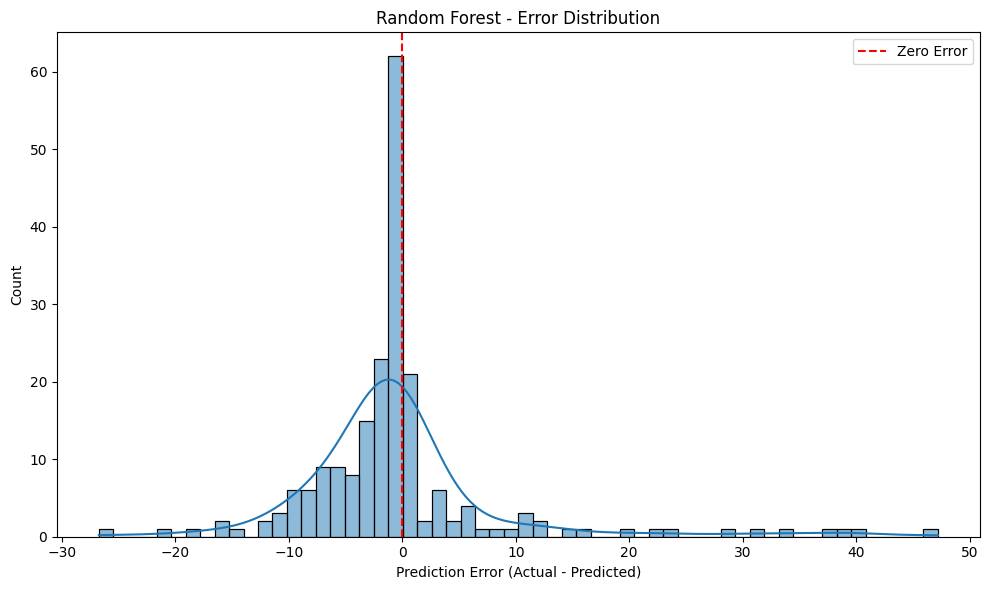

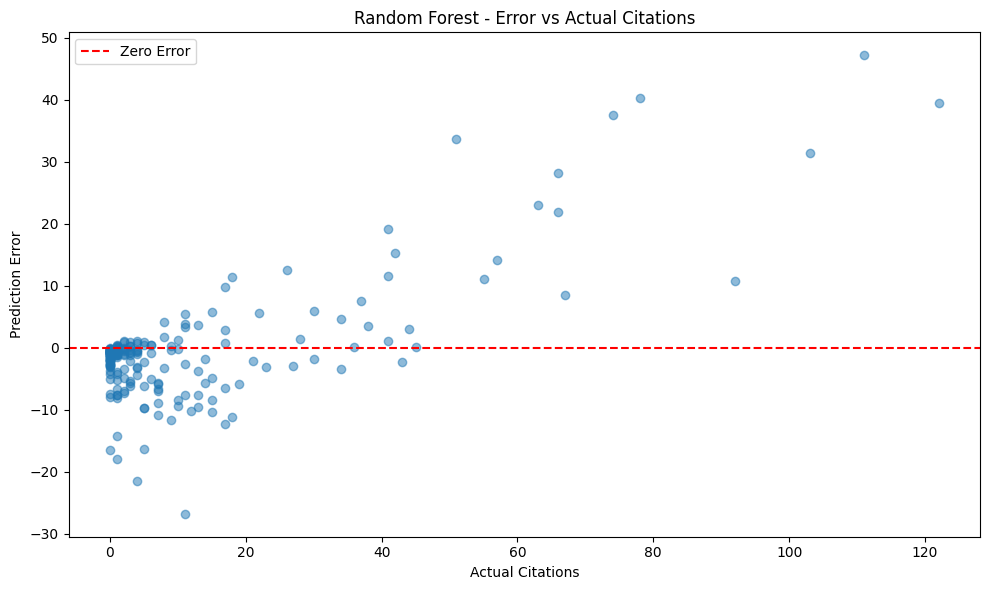

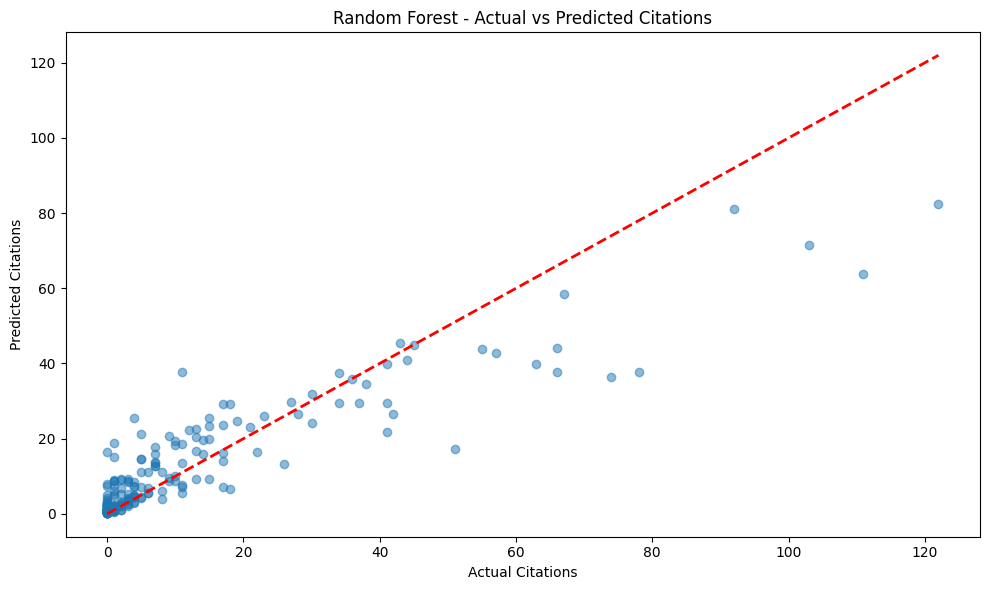

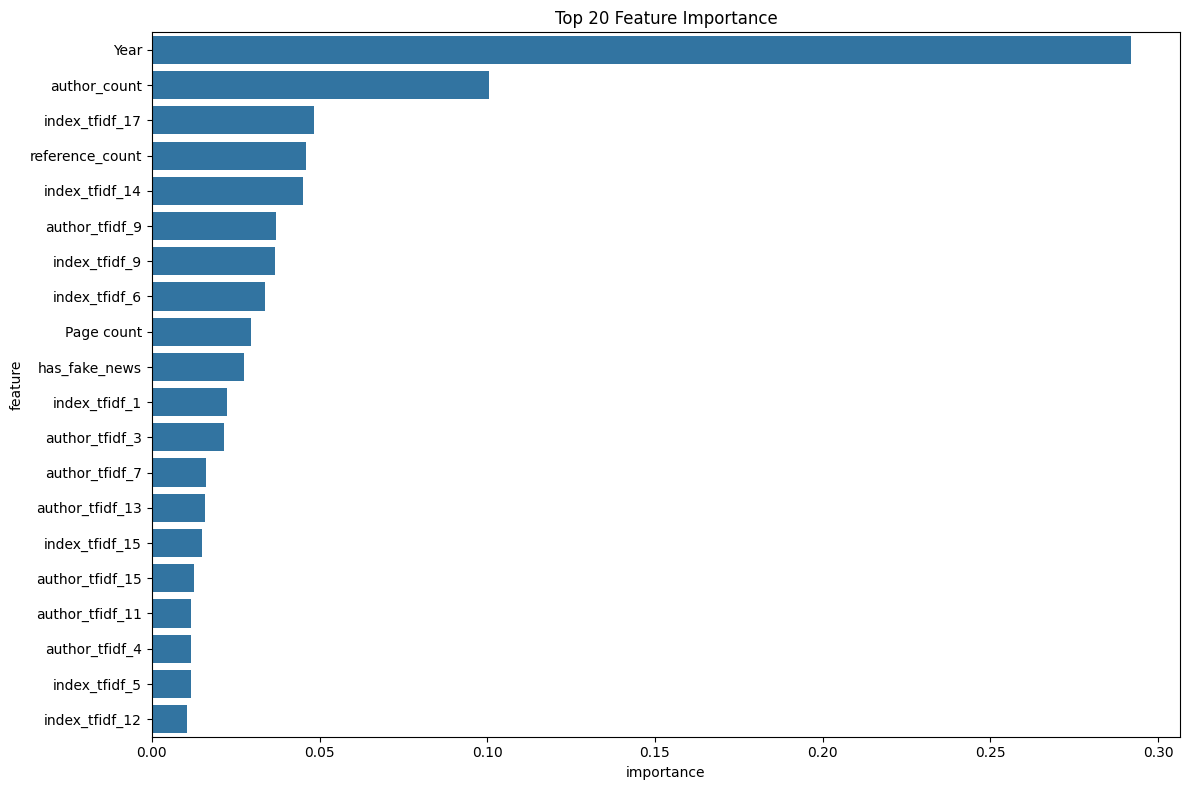


Top 20 Important Features:
            feature  importance
0              Year    0.291923
1      author_count    0.100580
82   index_tfidf_17    0.048315
3   reference_count    0.045850
79   index_tfidf_14    0.045023
54   author_tfidf_9    0.037056
74    index_tfidf_9    0.036867
71    index_tfidf_6    0.033814
2        Page count    0.029471
18    has_fake_news    0.027588
66    index_tfidf_1    0.022494
48   author_tfidf_3    0.021500
52   author_tfidf_7    0.016018
58  author_tfidf_13    0.015740
80   index_tfidf_15    0.015080
60  author_tfidf_15    0.012591
56  author_tfidf_11    0.011829
49   author_tfidf_4    0.011781
70    index_tfidf_5    0.011681
77   index_tfidf_12    0.010638

Training SVM...

Cross-validation R2 scores: [ 0.10290943  0.14000805 -0.04437121  0.09794443 -0.12807199]
Mean CV R2 score: 0.034 (+/- 0.205)

SVM Detailed Metrics:
Mean Squared Error (MSE): 305.28
Root Mean Squared Error (RMSE): 17.47
Mean Absolute Error (MAE): 6.46
R-squared Score: 0.29
Explaine

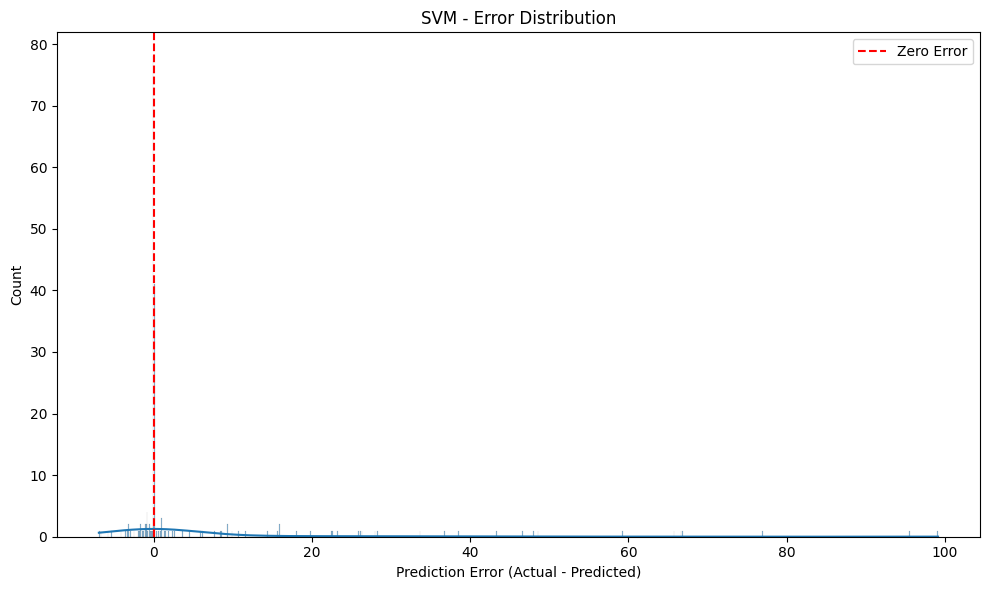

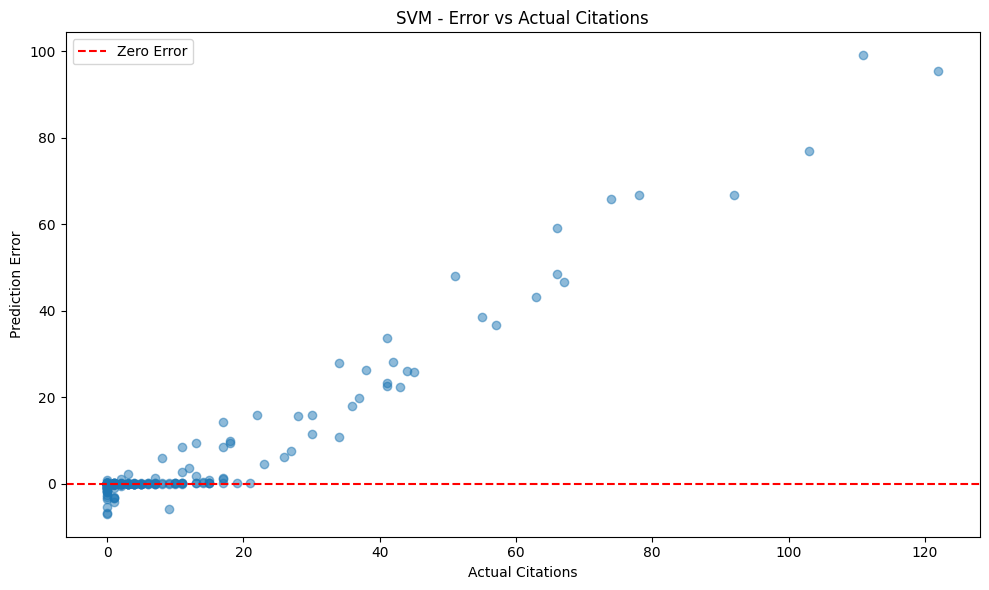

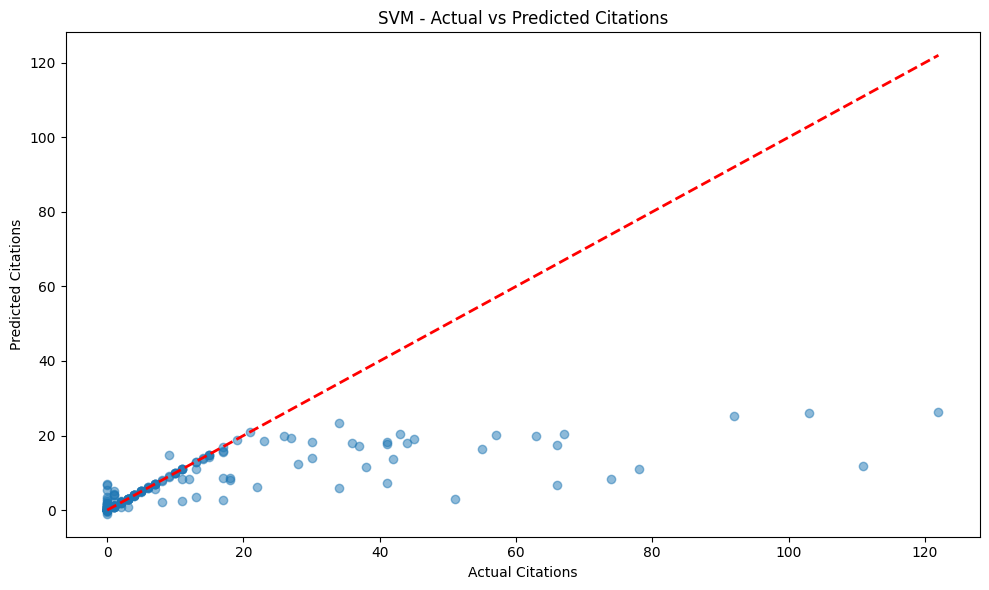


Model Comparison:
                      MSE       RMSE       MAE        R2 Explained Variance  \
Random Forest    86.69617   9.311078  5.190473  0.799379           0.799524   
SVM            305.283185  17.472355  6.459493  0.293552           0.369398   

              MAPE_non_zero      SMAPE  \
Random Forest    111.141234  95.920713   
SVM               32.764908  86.161839   

                                                     Error_Stats  \
Random Forest  {'mean_error': -0.25059108865141994, 'median_e...   
SVM            {'mean_error': 5.7250504999997025, 'median_err...   

                                               Error_Percentages  
Random Forest  {'within_1': 32.84313725490196, 'within_2': 47...  
SVM            {'within_1': 67.64705882352942, 'within_2': 74...  


<Figure size 1200x600 with 0 Axes>

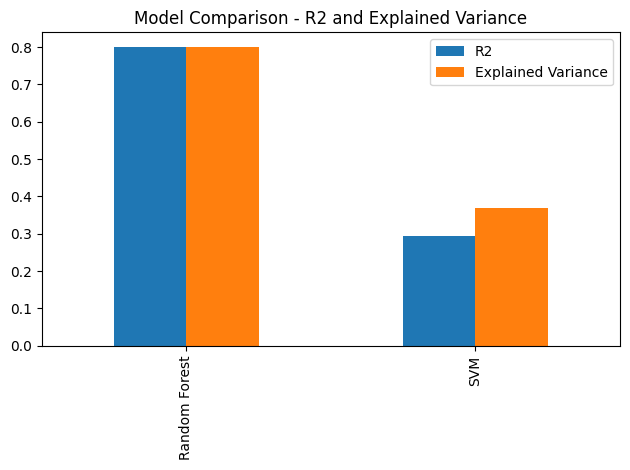


Best performing model: Random Forest


In [ ]:
# @title
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, explained_variance_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
import re
import joblib

def clean_keyword(keyword):
    keyword = keyword.lower().strip()
    keyword = re.sub(r'[^\w\s]', '', keyword)
    keyword = re.sub(r'\s+', ' ', keyword)
    return keyword

def load_and_preprocess_data(file_path):
    df = pd.read_csv(file_path)
    df = df[df['Document Type'] == 'Article']
    print(f"\nNumber of articles after filtering: {len(df)}")
    print("\nDataset Info:")
    print(df.info())
    print("\nFirst few rows:")
    print(df.head())
    return df

def process_keywords(keywords_series):
    all_keywords = []
    for keywords in keywords_series.dropna():
        keyword_list = [clean_keyword(k) for k in keywords.split(';')]
        all_keywords.extend(keyword_list)
    keyword_counter = Counter(all_keywords)
    top_keywords = [word for word, count in keyword_counter.most_common(20)]
    keyword_features = pd.DataFrame(index=keywords_series.index)
    for keyword in top_keywords:
        keyword_features[f'has_{keyword.replace(" ", "_")}'] = keywords_series.str.contains(
            keyword, case=False, na=False, regex=False
        ).astype(int)
    return keyword_features

def prepare_features(df):
    df_processed = df.copy()
    df_processed['author_count'] = df_processed['Authors'].str.count(';') + 1
    df_processed['Year'] = pd.to_numeric(df_processed['Year'], errors='coerce')
    df_processed['reference_count'] = df_processed['References'].str.count(';') + 1
    df_processed['reference_count'] = df_processed['reference_count'].fillna(0)
    df_processed['Page count'] = pd.to_numeric(df_processed['Page count'], errors='coerce')
    df_processed['is_open_access'] = df_processed['Open Access'].notna().astype(int)
    author_keyword_features = process_keywords(df_processed['Author Keywords'])
    index_keyword_features = process_keywords(df_processed['Index Keywords'])

    tfidf = TfidfVectorizer(max_features=20, stop_words='english')
    author_keywords_clean = df_processed['Author Keywords'].fillna('').apply(
        lambda x: ' '.join([clean_keyword(k) for k in x.split(';')])
    )
    author_keywords_tfidf = tfidf.fit_transform(author_keywords_clean)
    index_keywords_clean = df_processed['Index Keywords'].fillna('').apply(
        lambda x: ' '.join([clean_keyword(k) for k in x.split(';')])
    )
    index_keywords_tfidf = tfidf.fit_transform(index_keywords_clean)

    author_keywords_tfidf_df = pd.DataFrame(
        author_keywords_tfidf.toarray(),
        columns=[f'author_tfidf_{i}' for i in range(author_keywords_tfidf.shape[1])],
        index=df_processed.index
    )
    index_keywords_tfidf_df = pd.DataFrame(
        index_keywords_tfidf.toarray(),
        columns=[f'index_tfidf_{i}' for i in range(index_keywords_tfidf.shape[1])],
        index=df_processed.index
    )

    basic_features = ['Year', 'author_count', 'Page count', 'reference_count', 'is_open_access']
    for col in basic_features:
        if df_processed[col].isnull().any():
            df_processed[col] = df_processed[col].fillna(df_processed[col].median())

    X_basic = df_processed[basic_features]
    X = pd.concat([
        X_basic,
        author_keyword_features,
        index_keyword_features,
        author_keywords_tfidf_df,
        index_keywords_tfidf_df
    ], axis=1)
    y = df_processed['Cited by']
    print("\nFeature Statistics:")
    print(X.describe())
    print("\nTop Author Keywords:")
    print(author_keyword_features.columns.tolist())
    print("\nTop Index Keywords:")
    print(index_keyword_features.columns.tolist())
    return X, y

def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    explained_var = explained_variance_score(y_true, y_pred)
    mape_non_zero = np.mean(np.abs((y_true[y_true != 0] - y_pred[y_true != 0]) / y_true[y_true != 0])) * 100 if (y_true != 0).any() else np.nan
    smape = np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))) * 100 if (np.abs(y_true) + np.abs(y_pred)).any() else np.nan

    error_percentages = {
        'within_1': np.mean(np.abs(y_true - y_pred) <= 1) * 100,
        'within_2': np.mean(np.abs(y_true - y_pred) <= 2) * 100,
        'within_5': np.mean(np.abs(y_true - y_pred) <= 5) * 100,
        'within_10': np.mean(np.abs(y_true - y_pred) <= 10) * 100
    }
    errors = y_true - y_pred
    error_stats = {
        'mean_error': np.mean(errors),
        'median_error': np.median(errors),
        'std_error': np.std(errors),
        'min_error': np.min(errors),
        'max_error': np.max(errors)
    }

    print(f"\n{model_name} Detailed Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"R-squared Score: {r2:.2f}")
    print(f"Explained Variance Score: {explained_var:.2f}")
    print(f"\nError Distribution:")
    print(f"Mean Error: {error_stats['mean_error']:.2f}")
    print(f"Median Error: {error_stats['median_error']:.2f}")
    print(f"Standard Deviation of Error: {error_stats['std_error']:.2f}")
    print(f"Min Error: {error_stats['min_error']:.2f}")
    print(f"Max Error: {error_stats['max_error']:.2f}")
    print(f"\nPercentage Error Metrics:")
    print(f"MAPE (non-zero citations only): {mape_non_zero:.2f}%" if not np.isnan(mape_non_zero) else "MAPE (non-zero citations only): N/A")



    print(f"Symmetric MAPE (SMAPE): {smape:.2f}%" if not np.isnan(smape) else "Symmetric MAPE (SMAPE): N/A")
    print(f"\nPrediction Accuracy Ranges:")
    print(f"Predictions within ±1 citation: {error_percentages['within_1']:.2f}%")
    print(f"Predictions within ±2 citations: {error_percentages['within_2']:.2f}%")
    print(f"Predictions within ±5 citations: {error_percentages['within_5']:.2f}%")
    print(f"Predictions within ±10 citations: {error_percentages['within_10']:.2f}%")

    plt.figure(figsize=(10, 6))
    sns.histplot(errors, kde=True)
    plt.axvline(x=0, color='r', linestyle='--', label='Zero Error')
    plt.title(f'{model_name} - Error Distribution')
    plt.xlabel('Prediction Error (Actual - Predicted)')
    plt.ylabel('Count')
    plt.legend()
    plt.tight_layout()
    # plt.savefig(f'{model_name.lower().replace(" ", "_")}_error_distribution.png') # Uncomment to save plots
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.scatter(y_true, errors, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--', label='Zero Error')
    plt.title(f'{model_name} - Error vs Actual Citations')
    plt.xlabel('Actual Citations')
    plt.ylabel('Prediction Error')
    plt.legend()
    plt.tight_layout()
    # plt.savefig(f'{model_name.lower().replace(" ", "_")}_error_vs_actual.png') # Uncomment to save plots
    plt.show()

    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'Explained Variance': explained_var,
        'MAPE_non_zero': mape_non_zero,
        'SMAPE': smape,
        'Error_Stats': error_stats,
        'Error_Percentages': error_percentages
    }

def train_and_evaluate_models(X, y):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    models = {
        'Random Forest': RandomForestRegressor(
            n_estimators=200,
            max_depth=15,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42
        ),
        'SVM': SVR(kernel='rbf', C=10, epsilon=0.1)
    }
    results = {}
    for name, model in models.items():
        print(f"\nTraining {name}...")
        cv_scores = cross_val_score(model, X_scaled, y, cv=kf, scoring='r2')
        print(f"\nCross-validation R2 scores: {cv_scores}")
        print(f"Mean CV R2 score: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")
        model.fit(X_scaled, y)
        y_pred = model.predict(X_scaled)
        metrics = evaluate_model(y, y_pred, name)
        results[name] = {
            'model': model,
            'scaler': scaler,
            'metrics': metrics,
            'cv_scores': cv_scores
        }

        plt.figure(figsize=(10, 6))
        plt.scatter(y, y_pred, alpha=0.5)
        plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
        plt.xlabel('Actual Citations')
        plt.ylabel('Predicted Citations')
        plt.title(f'{name} - Actual vs Predicted Citations')
        plt.tight_layout()
        # plt.savefig(f'{name.lower().replace(" ", "_")}_predictions.png') # Uncomment to save plots
        plt.show()

        if name == 'Random Forest':
            feature_importance = pd.DataFrame({
                'feature': X.columns,
                'importance': model.feature_importances_
            }).sort_values('importance', ascending=False)
            plt.figure(figsize=(12, 8))
            sns.barplot(x='importance', y='feature', data=feature_importance.head(20))
            plt.title('Top 20 Feature Importance')
            plt.tight_layout()
            # plt.savefig('feature_importance.png') # Uncomment to save plots
            plt.show()
            print("\nTop 20 Important Features:")
            print(feature_importance.head(20))
    print("\nModel Comparison:")
    comparison_df = pd.DataFrame({
        name: results[name]['metrics'] for name in models.keys()
    }).T
    print(comparison_df)
    plt.figure(figsize=(12, 6))
    comparison_df[['R2', 'Explained Variance']].plot(kind='bar')
    plt.title('Model Comparison - R2 and Explained Variance')
    plt.tight_layout()
    # plt.savefig('model_comparison.png') # Uncomment to save plots
    plt.show()
    return results

def main():
    df = load_and_preprocess_data('/content/drive/MyDrive/DEEPFAKE877.csv')
    X, y = prepare_features(df)
    results = train_and_evaluate_models(X, y)
    best_model_name = max(results, key=lambda x: results[x]['metrics']['R2'])
    print(f"\nBest performing model: {best_model_name}")
    joblib.dump(results[best_model_name]['model'], 'best_model.joblib')
    joblib.dump(results[best_model_name]['scaler'], 'scaler.joblib')
    comparison_df = pd.DataFrame({
        name: results[name]['metrics'] for name in results.keys()
    }).T
    comparison_df.to_csv('model_comparison_results.csv')

if __name__ == "__main__":
    main()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


<IPython.core.display.Javascript object>

<ipython-input-50-96e4af5deddc>:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Normalized_Keywords"] = df["Author Keywords"].apply(extract_keywords)


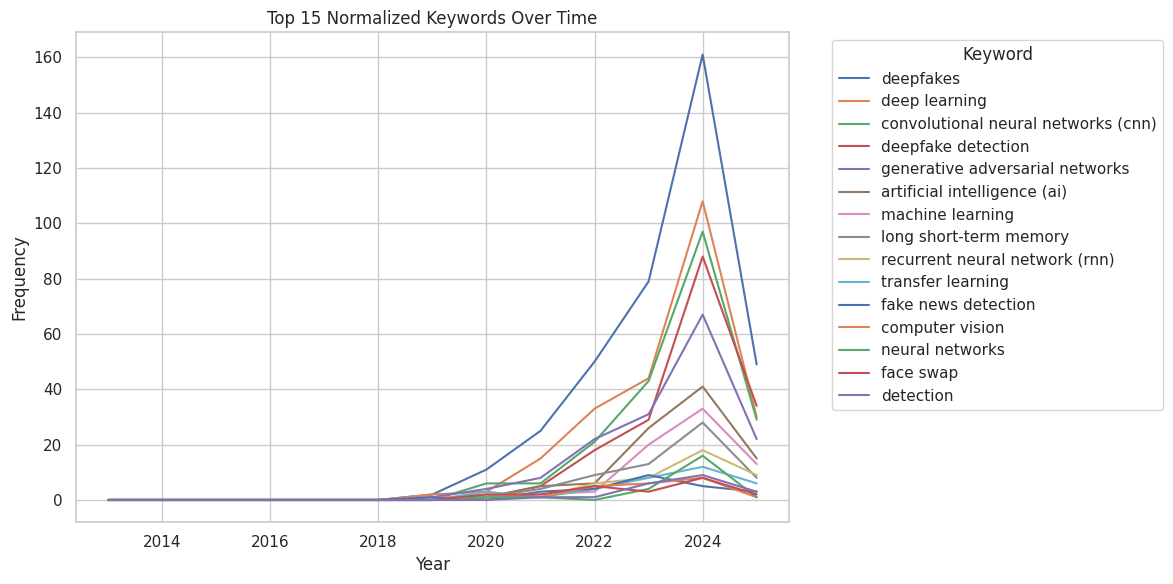


Total keyword mentions: 4358


In [ ]:
# @title

singular_plural_map = {
    'deepfake': 'deepfakes',
    'gan': 'generative adversarial networks',
    'gans': 'generative adversarial networks',
    'generative adversarial network': 'generative adversarial networks',
    'generative ai': 'generative adversarial networks',
    'generative adversarial networks (gan)': 'generative adversarial networks',
    'generative adversarial network (gan)': 'generative adversarial networks',
    'generative adversarial networks (gans)': 'generative adversarial networks',
    'deep fake': 'deepfakes',
    'deep-fake': 'deepfakes',
    'deep fakes': 'deepfakes',
    'cnn': 'convolutional neural networks (cnn)',
    'convolutional neural network (cnn)': 'convolutional neural networks (cnn)',
    'convolutional neural networks (cnns)': 'convolutional neural networks (cnn)',
    'convolutional neural networks': 'convolutional neural networks (cnn)',
    'convolutional neural network': 'convolutional neural networks (cnn)',
    'convolution neural networks': 'convolutional neural networks (cnn)',
    'convolution neural network': 'convolutional neural networks (cnn)',
    'deep fake detection': 'deepfake detection',
    'face swapping': 'face swap',
    'faceswap': 'face swap',
    'lstm': 'long short-term memory',
    'long short-term memory (lstm)': 'long short-term memory',
    'long-short term memory (lstm)': 'long short-term memory',
    'recurrent neural network': 'recurrent neural network (rnn)',
    'rnn': 'recurrent neural network (rnn)',
    'ai': 'artificial intelligence (ai)',
    'artificial intelligence ': 'artificial intelligence (ai)',
    'artificial intelligence': 'artificial intelligence (ai)',
    'fake news' : 'fake news detection',
    'audio deepfake': 'audio deepfake detection'
}

df = deepfake_rp_df.dropna(subset=["Year", "Author Keywords"])

# normalize
def normalize_keyword(kw):
    kw = kw.strip().lower()
    return singular_plural_map.get(kw, kw)

def extract_keywords(keyword_string):
    raw_keywords = str(keyword_string).split(';')
    return [normalize_keyword(k) for k in raw_keywords if k.strip()]

df["Normalized_Keywords"] = df["Author Keywords"].apply(extract_keywords)

# keywords count
keyword_counts_by_year = {}

for _, row in df.iterrows():
    year = int(row["Year"])
    keywords = row["Normalized_Keywords"]
    if year not in keyword_counts_by_year:
        keyword_counts_by_year[year] = Counter()
    keyword_counts_by_year[year].update(keywords)

all_keywords = set(k for year_data in keyword_counts_by_year.values() for k in year_data)
data = []

for year in sorted(keyword_counts_by_year.keys()):
    row = {"Year": year}
    for kw in all_keywords:
        row[kw] = keyword_counts_by_year[year][kw]
    data.append(row)

keyword_df = pd.DataFrame(data).fillna(0).set_index("Year")



top_n = 15
# print(all_keywords)
top_keywords = keyword_df.sum().sort_values(ascending=False).head(top_n).index

plt.figure(figsize=(12, 6))
for kw in top_keywords:
    sns.lineplot(data=keyword_df[kw], label=kw)

plt.title(f"Top {top_n} Normalized Keywords Over Time")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.legend(title="Keyword", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True);
plt.show();
total_keyword_counts = keyword_df.sum().sort_values(ascending=False)
total_mentions = total_keyword_counts.sum()
print(f"\nTotal keyword mentions: {total_mentions}")

<IPython.core.display.Javascript object>

<ipython-input-49-56c127154433>:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Normalized_Keywords"] = df["Index Keywords"].apply(extract_keywords)


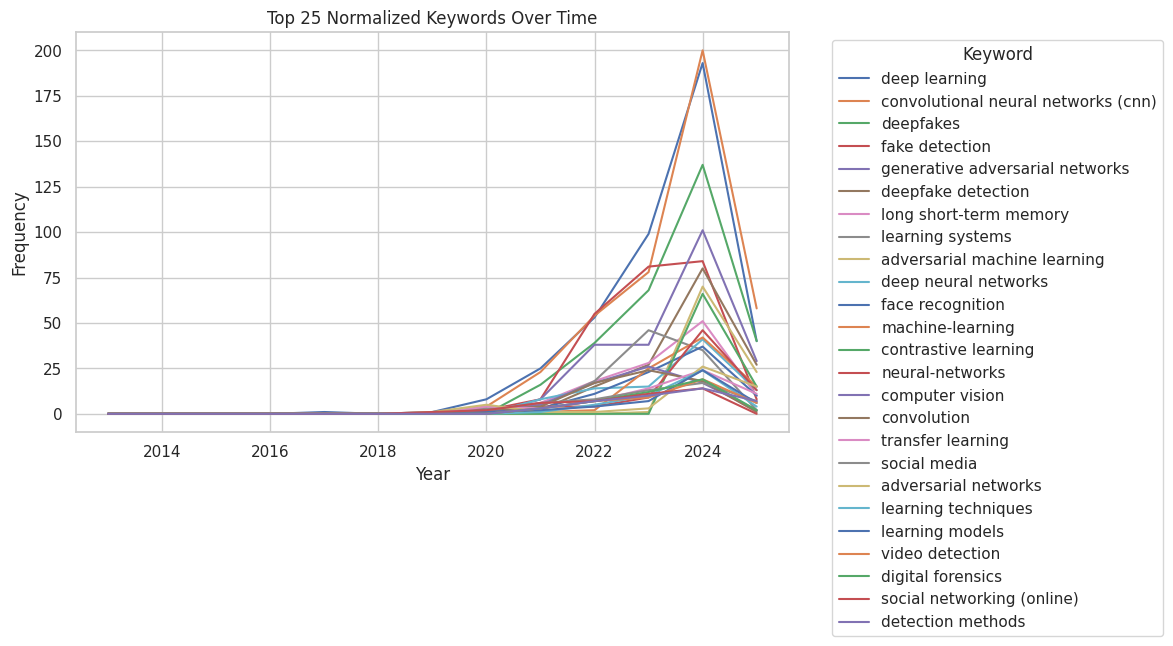

In [ ]:
# @title

singular_plural_map = {
    'deepfake': 'deepfakes',
    'gan': 'generative adversarial networks',
    'gans': 'generative adversarial networks',
    'generative adversarial network': 'generative adversarial networks',
    'generative ai': 'generative adversarial networks',
    'generative adversarial networks (gan)': 'generative adversarial networks',
    'generative adversarial network (gan)': 'generative adversarial networks',
    'generative adversarial networks (gans)': 'generative adversarial networks',
    'deep fake': 'deepfakes',
    'deep-fake': 'deepfakes',
    'deep fakes': 'deepfakes',
    'cnn': 'convolutional neural networks (cnn)',
    'convolutional neural network (cnn)': 'convolutional neural networks (cnn)',
    'convolutional neural networks (cnns)': 'convolutional neural networks (cnn)',
    'convolutional neural networks': 'convolutional neural networks (cnn)',
    'convolutional neural network': 'convolutional neural networks (cnn)',
    'convolution neural networks': 'convolutional neural networks (cnn)',
    'convolution neural network': 'convolutional neural networks (cnn)',
    'deep fake detection': 'deepfake detection',
    'face swapping': 'face swap',
    'faceswap': 'face swap',
    'lstm': 'long short-term memory',
    'long short-term memory (lstm)': 'long short-term memory',
    'long-short term memory (lstm)': 'long short-term memory',
    'recurrent neural network': 'recurrent neural network (rnn)',
    'rnn': 'recurrent neural network (rnn)',
    'ai': 'artificial intelligence (ai)',
    'artificial intelligence ': 'artificial intelligence (ai)',
    'artificial intelligence': 'artificial intelligence (ai)',
    'fake news' : 'fake news detection',
    'audio deepfake': 'audio deepfake detection'
}

df = deepfake_rp_df.dropna(subset=["Year", "Index Keywords"])

# normalize
def normalize_keyword(kw):
    kw = kw.strip().lower()
    return singular_plural_map.get(kw, kw)

def extract_keywords(keyword_string):
    raw_keywords = str(keyword_string).split(';')
    return [normalize_keyword(k) for k in raw_keywords if k.strip()]

df["Normalized_Keywords"] = df["Index Keywords"].apply(extract_keywords)

# keywords count
keyword_counts_by_year = {}

for _, row in df.iterrows():
    year = int(row["Year"])
    keywords = row["Normalized_Keywords"]
    if year not in keyword_counts_by_year:
        keyword_counts_by_year[year] = Counter()
    keyword_counts_by_year[year].update(keywords)

all_keywords = set(k for year_data in keyword_counts_by_year.values() for k in year_data)
data = []

for year in sorted(keyword_counts_by_year.keys()):
    row = {"Year": year}
    for kw in all_keywords:
        row[kw] = keyword_counts_by_year[year][kw]
    data.append(row)

keyword_df = pd.DataFrame(data).fillna(0).set_index("Year")



top_n = 25

top_keywords = keyword_df.sum().sort_values(ascending=False).head(top_n).index

plt.figure(figsize=(12, 6))
for kw in top_keywords:
    sns.lineplot(data=keyword_df[kw], label=kw)

plt.title(f"Top {top_n} Normalized Keywords Over Time")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.legend(title="Keyword", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True);
plt.show();

<IPython.core.display.Javascript object>

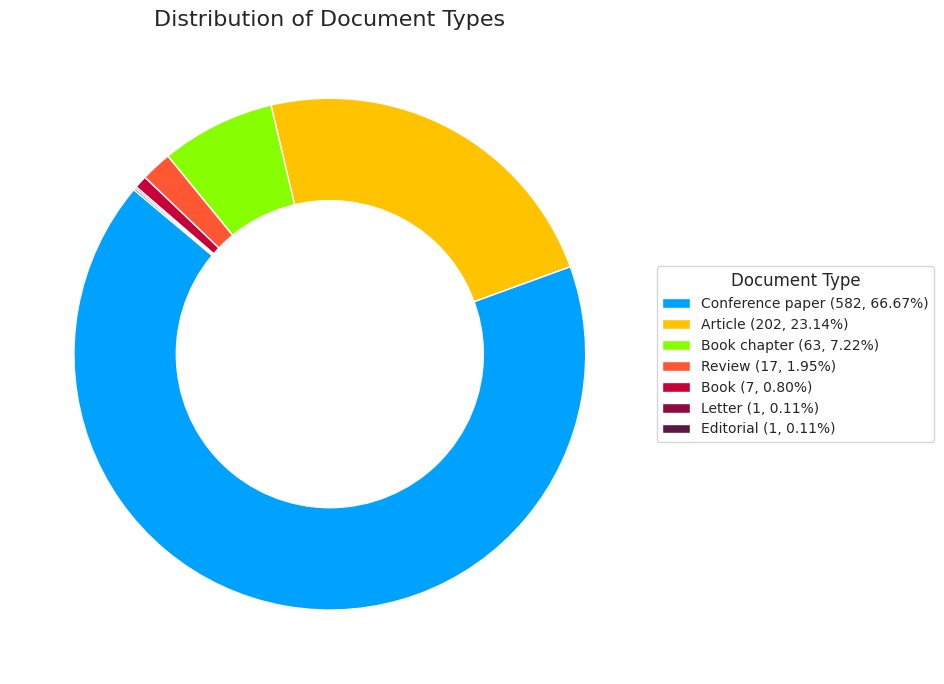

In [ ]:
# @title

doc_df = deepfake_rp_df[deepfake_rp_df['Document Type'].isin(
    ['Article', 'Conference paper','Book', 'Book chapter', 'Editorial', 'Letter','Review'])]
Value_count = doc_df['Document Type'].value_counts()
plt.figure(figsize=(9, 7))


colors= ['#00a2ff', '#FFC300', '#87ff00','#FF5733','#C70039','#900C3F','#581845']
wedges, texts = plt.pie(
    Value_count,
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

centre_circle = plt.Circle((0, 0), 0.60, fc='white')
plt.gca().add_artist(centre_circle)

plt.title('Distribution of Document Types', fontsize=16)
legend_labels = [f"{label} ({count}, {pct:.2f}%)" for label, count, pct in zip(
    Value_count.index,
    Value_count.values,
    100 * Value_count.values / Value_count.values.sum()
)]
plt.legend(wedges, legend_labels, title="Document Type", loc="center left", bbox_to_anchor=(1, 0.5), fontsize=10)

plt.tight_layout()
plt.show()


<IPython.core.display.Javascript object>

<ipython-input-47-886447cbe3b6>:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Year"] = df["Year"].astype(int)


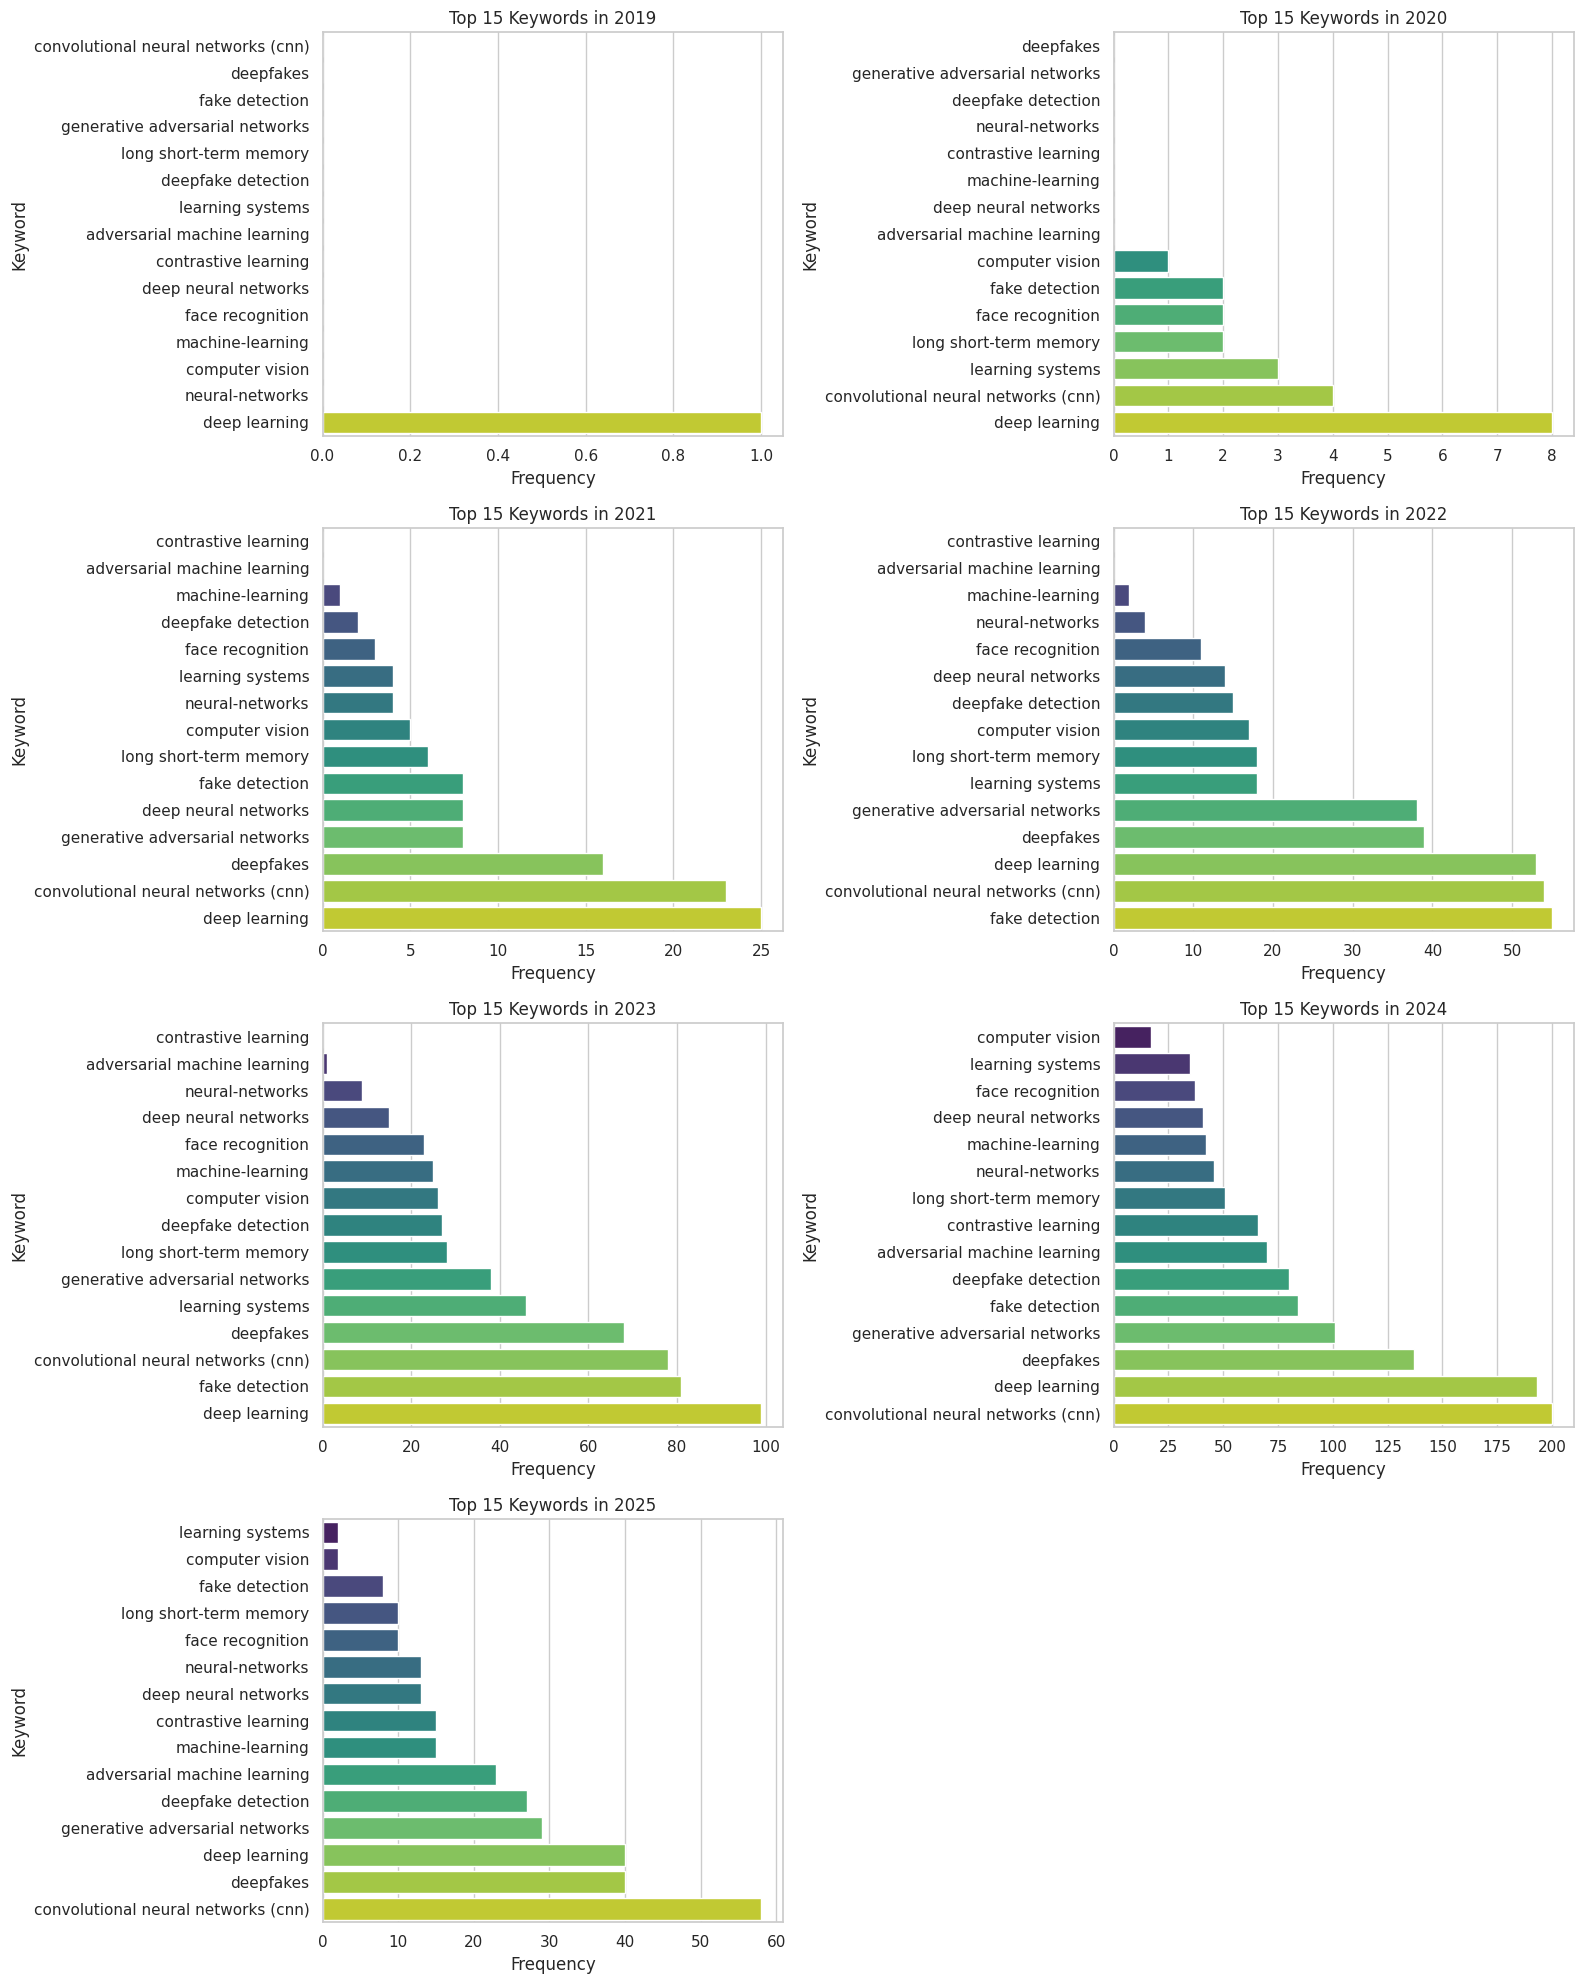

In [ ]:
# @title
singular_plural_map = {
    'deepfake': 'deepfakes',
    'gan': 'generative adversarial networks',
    'gans': 'generative adversarial networks',
    'generative adversarial network': 'generative adversarial networks',
    'generative ai': 'generative adversarial networks',
    'generative adversarial networks (gan)': 'generative adversarial networks',
    'generative adversarial network (gan)': 'generative adversarial networks',
    'generative adversarial networks (gans)': 'generative adversarial networks',
    'deep fake': 'deepfakes',
    'deep-fake': 'deepfakes',
    'deep fakes': 'deepfakes',
    'cnn': 'convolutional neural networks (cnn)',
    'convolutional neural network (cnn)': 'convolutional neural networks (cnn)',
    'convolutional neural networks (cnns)': 'convolutional neural networks (cnn)',
    'convolutional neural networks': 'convolutional neural networks (cnn)',
    'convolutional neural network': 'convolutional neural networks (cnn)',
    'convolution neural networks': 'convolutional neural networks (cnn)',
    'convolution neural network': 'convolutional neural networks (cnn)',
    'deep fake detection': 'deepfake detection',
    'face swapping': 'face swap',
    'faceswap': 'face swap',
    'lstm': 'long short-term memory',
    'long short-term memory (lstm)': 'long short-term memory',
    'long-short term memory (lstm)': 'long short-term memory',
    'recurrent neural network': 'recurrent neural network (rnn)',
    'rnn': 'recurrent neural network (rnn)',
    'ai': 'artificial intelligence (ai)',
    'artificial intelligence ': 'artificial intelligence (ai)',
    'artificial intelligence': 'artificial intelligence (ai)',
    'fake news': 'fake news detection',
    'audio deepfake': 'audio deepfake detection'
}

def normalize_keyword(kw):
    kw = kw.strip().lower()
    return singular_plural_map.get(kw, kw)

def extract_keywords(keyword_string):
    raw_keywords = str(keyword_string).split(';')
    return [normalize_keyword(k) for k in raw_keywords if k.strip()]

df = deepfake_rp_df.dropna(subset=["Year", "Index Keywords"])
df["Year"] = df["Year"].astype(int)
df = df[df["Year"] >= 2019]
df["Normalized_Keywords"] = df["Index Keywords"].apply(extract_keywords)

keyword_counts_by_year = {}
for _, row in df.iterrows():
    year = row["Year"]
    keywords = row["Normalized_Keywords"]
    if year not in keyword_counts_by_year:
        keyword_counts_by_year[year] = Counter()
    keyword_counts_by_year[year].update(keywords)


all_keywords = set(k for year_data in keyword_counts_by_year.values() for k in year_data)
data = []
for year in sorted(keyword_counts_by_year.keys()):
    row = {"Year": year}
    for kw in all_keywords:
        row[kw] = keyword_counts_by_year[year][kw]
    data.append(row)

keyword_df = pd.DataFrame(data).fillna(0).set_index("Year")

top_n = 15
top_keywords = keyword_df.sum().sort_values(ascending=False).head(top_n).index
filtered_df = keyword_df[top_keywords]

years = sorted(filtered_df.index)
n_years = len(years)
ncols = 2
nrows = (n_years + ncols - 1) // ncols

sns.set(style="whitegrid")
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 5 * nrows))
axes = axes.flatten()

for i, year in enumerate(years):
    ax = axes[i]
    year_data = filtered_df.loc[year].sort_values(ascending=True)
    sns.barplot(x=year_data.values, y=year_data.index, hue=year_data.index, ax=ax, palette='viridis', legend=False)

    ax.set_title(f"Top {top_n} Keywords in {year}")
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Keyword")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


<IPython.core.display.Javascript object>

<ipython-input-46-78b038d76252>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Year'] = pd.to_numeric(filtered_df['Year'], errors='coerce')


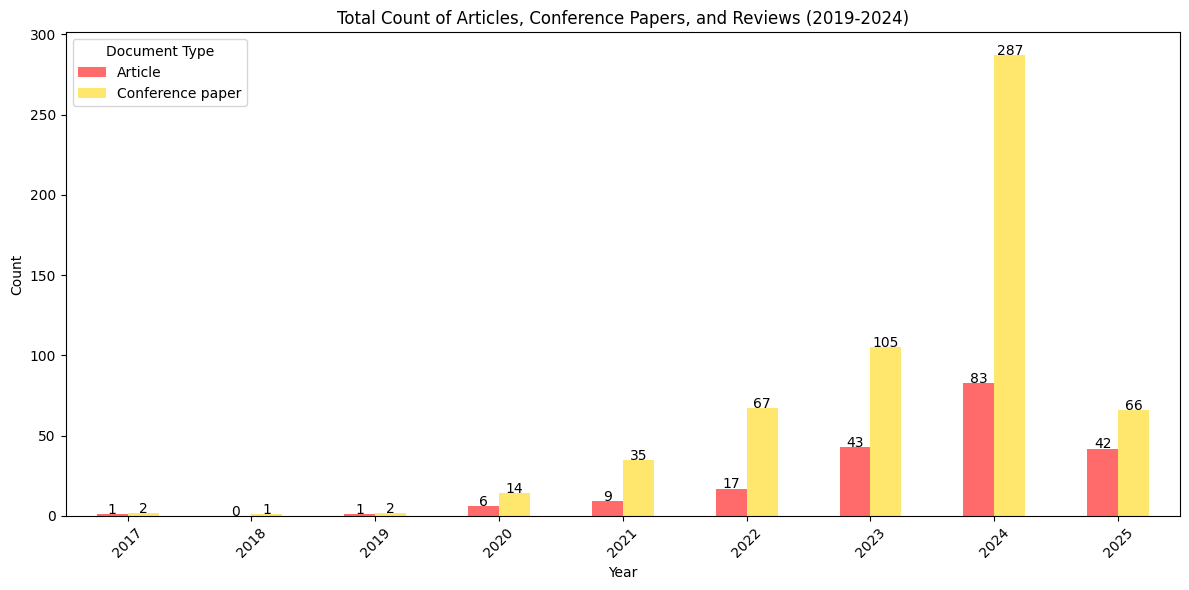

In [ ]:
# @title
filtered_df = deepfake_rp_df[deepfake_rp_df['Document Type'].isin(['Article', 'Conference paper'])]

filtered_df['Year'] = pd.to_numeric(filtered_df['Year'], errors='coerce')

filtered_df = filtered_df[filtered_df['Year'].between(2017, 2025, inclusive='both')]

grouped_data = filtered_df.groupby(['Year', 'Document Type']).size().unstack(fill_value=0)

totals = grouped_data

ax = totals.plot(kind='bar', figsize=(12, 6), color=['#ff6b6b','#ffe66d'])

# Add counts on bar
for i in ax.containers:
    for bar in i:
        height = bar.get_height()
        ax.annotate(f'{int(height)}',
                    (bar.get_x() + bar.get_width() / 2, height),
                    ha='center', va='center', xytext=(0, 3),
                    textcoords='offset points')

plt.title('Total Count of Articles, Conference Papers, and Reviews (2019-2024)')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(title='Document Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
